In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

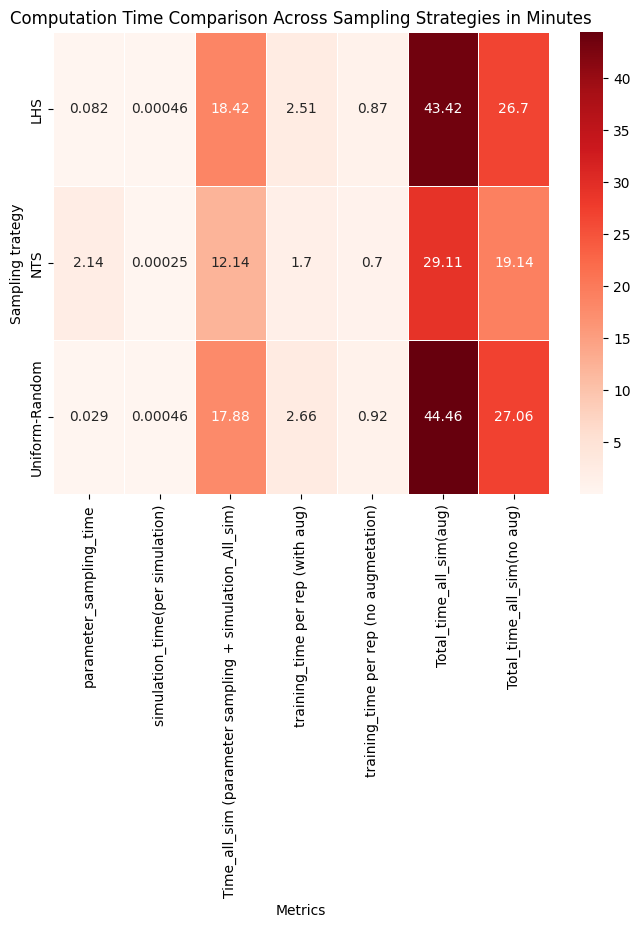

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

data = pd.DataFrame({
    'parameter_sampling_time': [0.082, 2.14,0.029],
    'simulation_time(per simulation)': [ 0.00046, 0.00025, 0.00046],
    'Time_all_sim (parameter sampling + simulation_All_sim)': [ 18.42, 12.14, 17.88],
    'training_time per rep (with aug)': [2.51, 1.70, 2.66],
    'training_time per rep (no augmetation)': [0.87, 0.70, 0.92],
    'Total_time_all_sim(aug)': [43.42,29.11 ,44.46],
    'Total_time_all_sim(no aug)': [26.7, 19.14, 27.06]
}, index=['LHS', 'NTS', 'Uniform-Random'])

plt.figure(figsize=(8, 6))

sns.heatmap(
    data,
    annot=True,
    cmap='Reds',
    linewidths=0.5,
    fmt=""
)

plt.title("Computation Time Comparison Across Sampling Strategies in Minutes")
plt.ylabel("Sampling trategy")
plt.xlabel("Metrics")
plt.show()


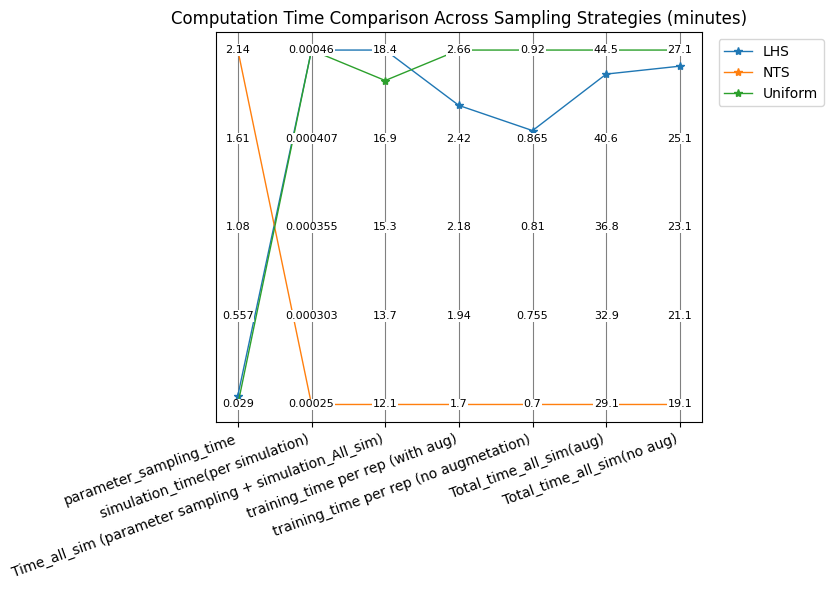

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'parameter_sampling_time': [0.082, 2.14, 0.029],
    'simulation_time(per simulation)': [0.00046, 0.00025, 0.00046],
    'Time_all_sim (parameter sampling + simulation_All_sim)': [18.42, 12.14, 17.88],
    'training_time per rep (with aug)': [2.51, 1.70, 2.66],
    'training_time per rep (no augmetation)': [0.87, 0.70, 0.92],
    'Total_time_all_sim(aug)': [43.42, 29.11, 44.46],
    'Total_time_all_sim(no aug)': [26.7, 19.14, 27.06]
}, index=['LHS', 'NTS', 'Uniform'])

# Parallel coordinates plot. Each metric spans a very different range
# (e.g. 0.00025 to 44.46), so every axis is min-max normalized to [0, 1]
# purely for plotting position; the real values are printed as tick
# labels alongside each vertical axis instead of the shared 0-1 scale.
cols = data.columns
n_cols = len(cols)
x = np.arange(n_cols)

norm_data = (data - data.min()) / (data.max() - data.min())
norm_data = norm_data.fillna(0.5)  # guards against a constant column (max == min)

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.tab10.colors
for i, (name, row) in enumerate(norm_data.iterrows()):
    ax.plot(x, row.values, marker='*', linewidth=1, color=colors[i], label=name, zorder=2)

n_ticks = 5
for j, col in enumerate(cols):
    ax.axvline(x[j], color='grey', linewidth=0.8, zorder=1)
    col_min, col_max = data[col].min(), data[col].max()
    for t in np.linspace(0, 1, n_ticks):
        real_val = col_min + t * (col_max - col_min)
        ax.text(x[j], t, f'{real_val:.3g}', ha='center', va='center', fontsize=8,
                zorder=2, bbox=dict(facecolor='white', edgecolor='none', pad=0.5))

ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=20, ha='right')
ax.set_yticks([])
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-0.3, n_cols - 0.7)
ax.set_title("Computation Time Comparison Across Sampling Strategies (minutes)")
ax.legend( loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


**MCMC TRAINED AND TESTED ON MCMC DATA**

*MCMC_MCMC-(No Augmentation)*\
$\mathrm{Rel-MLE}_{I}=5.79\%$ \ 
Relative Error near threshold:$0$--$10$ \

*MCMC_MCMC-(Augmentation)*\
$\mathrm{Rel-MLE}_{I}=4.56\%$\
Relative Error near threshold:$0-10\%$ 
Percentage change: $-21.24\% $

**LHS TRAINED AND TESTED ON LHS DATA**

*LHS_LHS-(No Augmentation)*
$\mathrm{Rel-MLE}_{I}=7.84\%$ 
Relative Error near threshold:$0-50\%$

*LHS_LHS-(Augmentation)*    
$\mathrm{Rel-MLE}_{I}=6.80\%$\
Relative Error near threshold:$2-20\%$ 
Percentage change: $-13.26\% $

**UNIFORM RANDOM TRAINED AND TESTED ON UNIFORM RANDOM DATA**

*UNIFORM-UNIFORM (No Augmentation)*\
$\mathrm{Rel-MLE}_{I}=6.83\%$ 
Relative Error near threshold:$0-50\%$

*UNIFORM-UNIFORM-(Augmentation)*\     
$\mathrm{Rel-MLE}_{I}=4.80\%$\
Relative Error near threshold:$0-50\%$ 
Percentage change: $-13.26\% $\


**MCMC TRAINED MODEL ON OUT OF SAMPLE DATA**

*MCMC_LHS (No Augmentation)*\
$\mathrm{Rel-MLE}_{I}=6.72\%$      
Relative Error near threshold:$0-20$

*MCMC_LHS (Augmentation)*\
$\mathrm{Rel-MLE}_{I}=5.62\%$\
Relative Error near threshold:$0-10$
Percentage change: $-16\% $\

*MCMC_Random (No Augmentation )*    
No Augmentation  $\mathrm{Rel-MLE}_{I}=6.81\%$\
Relative Error near threshold:$2-20%$

*MCMC_Random (Augmentation )*   
$\mathrm{Rel-MLE}_{I}=5.79\%$\ 
Relative Error near threshold:$0-10%$
Percentage change= $-13.26%$\

**LHS TRAINED MODEL ON MCMC TEST DATA**

*LHS_MCMC (No Augmentation )*\
$\mathrm{Rel-MLE}_{I}=9.04\%$\     
Relative Error near threshold:$0-50\%$

*LHS_MCMC (Augmentation )*\
$\mathrm{Rel-MLE}_{I}=7.84\%$\
Relative Error near threshold:$0-25\%$
Percentage change: $-13.27\% $\

**UNIFORM RANDOM TRAINED MODEL ON MCMC TEST DATA**

*UNIFORM_MCMC (No Augmentation)*\
$\mathrm{Rel-MLE}_{I}=9.57\%$ \ 
Relative Error near threshold:$0-50\%$    

*UNIFORM_MCMC ( Augmentation)*\
$\mathrm{Rel-MLE}_{I}=6.31\%$\
Relative Error near threshold:$0-25$
Percentage change: $-34.06\% $\



In [5]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir_candidates = [
    Path("experiments/Regression/data"),
    Path("data"),
]
DATA_DIR = next((path for path in data_dir_candidates if path.exists()), None)

csv_files = sorted(DATA_DIR.rglob("replicate_results_*.csv"))

dfs = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    df["source_file"] = csv_file.name
    dfs.append(df)

print(f"Found {len(dfs)} condition files in {DATA_DIR.resolve()}:")
for csv_file in csv_files:
    print(f"- {csv_file.name}")

master_df = pd.concat(dfs, ignore_index=True)
master_df.to_csv(DATA_DIR / "master_results.csv", index=False)
master_df


Found 18 condition files in C:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\experiments\Regression\data:
- replicate_results_LHS_to_LHS_aug0.csv
- replicate_results_LHS_to_LHS_aug1.csv
- replicate_results_LHS_to_MCMC_aug0.csv
- replicate_results_LHS_to_MCMC_aug1.csv
- replicate_results_LHS_to_UNIFORM_RANDOM_aug0.csv
- replicate_results_LHS_to_UNIFORM_RANDOM_aug1.csv
- replicate_results_MCMC_to_LHS_aug0.csv
- replicate_results_MCMC_to_LHS_aug1.csv
- replicate_results_MCMC_to_MCMC_aug0.csv
- replicate_results_MCMC_to_MCMC_aug1.csv
- replicate_results_MCMC_to_UNIFORM_RANDOM_aug0.csv
- replicate_results_MCMC_to_UNIFORM_RANDOM_aug1.csv
- replicate_results_UNIFORM_RANDOM_to_LHS_aug0.csv
- replicate_results_UNIFORM_RANDOM_to_LHS_aug1.csv
- replicate_results_UNIFORM_RANDOM_to_MCMC_aug0.csv
- replicate_results_UNIFORM_RANDOM_to_MCMC_aug1.csv
- replicate_results_UNIFORM_RANDOM_to_UNIFORM_RANDOM_aug0.csv
- replicate_results_UNIFORM_RANDOM_to_UNIF

,replicate_id,train_strategy,test_strategy,augmentation,in_domain,n_train_simulations,relative_MAE_I,R2_I,MAE_I,R2_S,...,MAE_S,MAE_R,RMSE,MSE,mean_peak_I,n_test_samples,model_path,training_epoch,source_file,peak_I
0,1,LHS,LHS,0,0,2800,6.2988,0.935098,163.2279,0.985955,...,1559.2844,1559.6222,2237.8757,5008087.50,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,99,replicate_results_LHS_to_LHS_aug0.csv,NaN
1,2,LHS,LHS,0,0,2800,6.6589,0.937894,158.8861,0.986880,...,1534.6743,1525.9868,2153.0298,4635537.50,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,96,replicate_results_LHS_to_LHS_aug0.csv,NaN
2,3,LHS,LHS,0,0,2800,6.3992,0.936721,155.7145,0.986076,...,1490.1917,1475.8263,2212.3149,4894337.00,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,94,replicate_results_LHS_to_LHS_aug0.csv,NaN
3,4,LHS,LHS,0,0,2800,6.6328,0.937746,156.9570,0.986406,...,1467.7682,1454.2513,2183.0349,4765641.50,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,99,replicate_results_LHS_to_LHS_aug0.csv,NaN
4,5,LHS,LHS,0,0,2800,6.7951,0.933664,161.0186,0.986697,...,1463.4814,1449.3961,2164.9404,4686967.00,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,98,replicate_results_LHS_to_LHS_aug0.csv,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,6,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.4279,0.958464,141.6713,0.990740,...,1254.8110,1226.2889,1877.0487,3523312.00,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN
176,7,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.3698,0.962265,131.4522,0.991901,...,1092.2500,1074.4663,1761.5143,3102932.50,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN
177,8,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.2783,0.957199,138.9727,0.990851,...,1316.8821,1290.1155,1867.6126,3487976.75,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN
178,9,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.2387,0.961638,132.6006,0.991374,...,1140.0293,1128.9860,1825.9504,3334095.00,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN


In [6]:
master_df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['replicate_id', 'train_strategy', 'test_strategy', 'augmentation',
       'in_domain', 'n_train_simulations', 'relative_MAE_I', 'R2_I', 'MAE_I',
       'R2_S', 'R2_R', 'R2_overall', 'MAE_S', 'MAE_R', 'RMSE', 'MSE',
       'mean_peak_I', 'n_test_samples', 'model_path', 'training_epoch',
       'source_file', 'peak_I'],
      dtype='object')>

In [7]:
master_df.shape
master_df.columns
master_df.isnull().sum()
master_df.describe()

master_df['condition_id'] = (
    master_df['train_strategy'] + '_' +
    master_df['test_strategy']  + '_' +
    master_df['augmentation'].astype(str)
)

master_df.tail()
master_cv=master_df.to_csv(DATA_DIR / "master_results.csv", index=False)

In [8]:
import numpy as np
from scipy import stats as scipy_stats

master_df["log_relative_MAE_I"] = np.log(master_df["relative_MAE_I"])

skew_rel= scipy_stats.skew(master_df["relative_MAE_I"])
skew_log_rel = scipy_stats.skew(master_df["log_relative_MAE_I"])

print(f"Skewness of relative_MAE_I:      {skew_rel:.4f}")
print(f"Skewness of log(relative_MAE_I): {skew_log_rel:.4f}")



Skewness of relative_MAE_I:      0.9189
Skewness of log(relative_MAE_I): 0.6816


In [9]:
master_df.columns.tolist()
master_df['condition_id'].unique()
master_df.head()

,replicate_id,train_strategy,test_strategy,augmentation,in_domain,n_train_simulations,relative_MAE_I,R2_I,MAE_I,R2_S,...,RMSE,MSE,mean_peak_I,n_test_samples,model_path,training_epoch,source_file,peak_I,condition_id,log_relative_MAE_I
0,1,LHS,LHS,0,0,2800,6.2988,0.935098,163.2279,0.985955,...,2237.8757,5008087.5,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,99,replicate_results_LHS_to_LHS_aug0.csv,NaN,LHS_LHS_0,1.840359
1,2,LHS,LHS,0,0,2800,6.6589,0.937894,158.8861,0.986880,...,2153.0298,4635537.5,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,96,replicate_results_LHS_to_LHS_aug0.csv,NaN,LHS_LHS_0,1.895954
2,3,LHS,LHS,0,0,2800,6.3992,0.936721,155.7145,0.986076,...,2212.3149,4894337.0,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,94,replicate_results_LHS_to_LHS_aug0.csv,NaN,LHS_LHS_0,1.856173
3,4,LHS,LHS,0,0,2800,6.6328,0.937746,156.9570,0.986406,...,2183.0349,4765641.5,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,99,replicate_results_LHS_to_LHS_aug0.csv,NaN,LHS_LHS_0,1.892027
4,5,LHS,LHS,0,0,2800,6.7951,0.933664,161.0186,0.986697,...,2164.9404,4686967.0,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,98,replicate_results_LHS_to_LHS_aug0.csv,NaN,LHS_LHS_0,1.916202


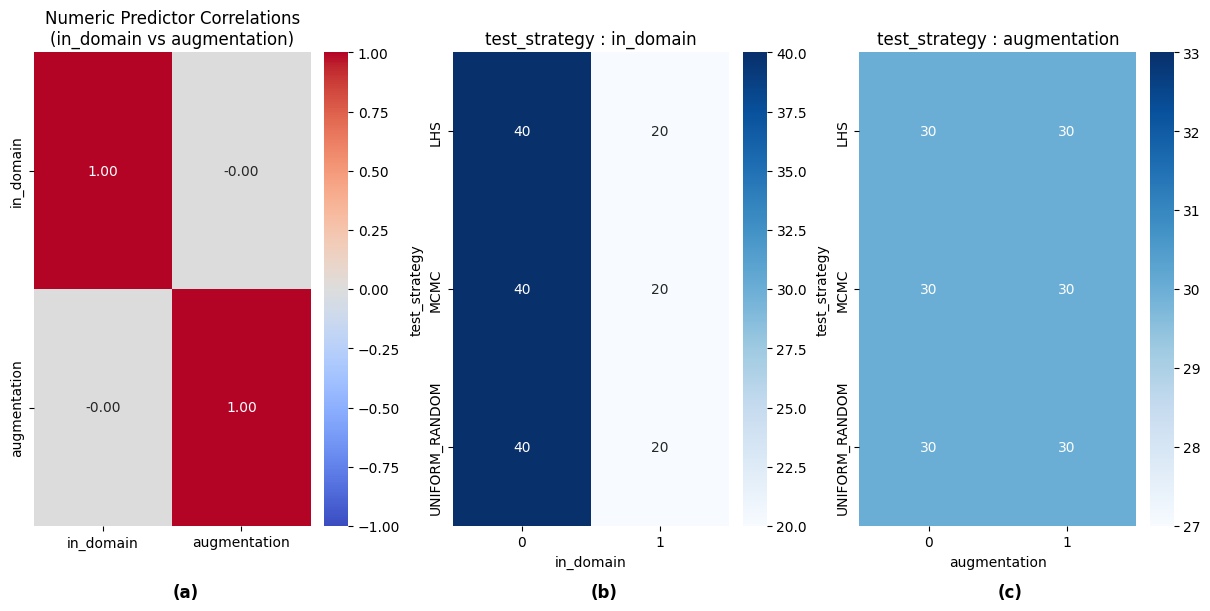

Numeric correlation (in_domain vs augmentation):
              in_domain  augmentation
in_domain           1.0          -0.0
augmentation       -0.0           1.0

Cross-tabulation: test_strategy : in_domain
in_domain        0   1
test_strategy         
LHS             40  20
MCMC            40  20
UNIFORM_RANDOM  40  20

Cross-tabulation: test_strategy : augmentation
augmentation     0   1
test_strategy         
LHS             30  30
MCMC            30  30
UNIFORM_RANDOM  30  30


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True)

# --- 1. Correlation heatmap for numeric predictors (in_domain & augmentation) ---

   
corr = master_df[ ['in_domain', 'augmentation']].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Numeric Predictor Correlations\n(in_domain vs augmentation)")
axes[0].text(0.5, -0.15, "(a)", transform=axes[0].transAxes, fontsize=12, fontweight='bold')

#  Cross-tabulation: test_strategy : in_domain
cross_tab1 = pd.crosstab(master_df['test_strategy'], master_df['in_domain'])
sns.heatmap(cross_tab1 , annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("test_strategy : in_domain")
axes[1].set_xlabel("in_domain")
axes[1].text(0.5, -0.15, "(b)", transform=axes[1].transAxes, fontsize=12, fontweight='bold')

# Cross-tabulation: test_strategy : augmentation
cross_tab2 = pd.crosstab(master_df['test_strategy'], master_df['augmentation'])
sns.heatmap(cross_tab2, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("test_strategy : augmentation")
axes[2].set_xlabel("augmentation")
axes[2].text(0.5, -0.15, "(c)", transform=axes[2].transAxes, fontsize=12, fontweight='bold')

fig.savefig("fig_multicollinearity_check.png", dpi=600)
plt.show()

print("Numeric correlation (in_domain vs augmentation):")
print(corr.round(3))
print("\nCross-tabulation: test_strategy : in_domain")
print(cross_tab1)
print("\nCross-tabulation: test_strategy : augmentation")
print(cross_tab2)


In [11]:
master_df.columns.tolist()
# master_df["test_strategy"]
master_df['train_strategy'].value_counts()
master_df['train_strategy'].unique()
master_df['test_strategy'].unique()


array(['LHS', 'MCMC', 'UNIFORM_RANDOM'], dtype=object)

In [12]:
from sklearn.linear_model import LinearRegression
import patsy
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns 

# Ensure condition_id and log targets exist regardless of cell execution order
if 'condition_id' not in master_df.columns:
    master_df['condition_id'] = (
        master_df['train_strategy'] + '_' +
        master_df['test_strategy']  + '_' +
        master_df['augmentation'].astype(str)
    )
if 'log_relative_MAE_I' not in master_df.columns:
    master_df['log_relative_MAE_I'] = np.log(master_df['relative_MAE_I'])

regresion_model = ('log_relative_MAE_I '
    '~ C(train_strategy, Treatment("LHS"))'
    '+ C(test_strategy, Treatment("LHS")) '
    '+ augmentation'
     '+train_strategy:augmentation'
   
)

y_mat, X_mat = patsy.dmatrices(regresion_model, data=master_df, return_type='dataframe')

ols_model = sm.OLS(y_mat, X_mat).fit()
print(ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:     log_relative_MAE_I   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     298.3
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           1.14e-92
Time:                        05:16:09   Log-Likelihood:                 255.62
No. Observations:                 180   AIC:                            -495.2
Df Residuals:                     172   BIC:                            -469.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [13]:
from sklearn.linear_model import LinearRegression
import patsy
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns 

# Ensure condition_id and log targets exist regardless of cell execution order
if 'condition_id' not in master_df.columns:
    master_df['condition_id'] = (
        master_df['train_strategy'] + '_' +
        master_df['test_strategy']  + '_' +
        master_df['augmentation'].astype(str)
    )
if 'log_relative_MAE_I' not in master_df.columns:
    master_df['log_relative_MAE_I'] = np.log(master_df['relative_MAE_I'])

regresion_model_cluster = ('log_relative_MAE_I '
    '~ C(train_strategy, Treatment("LHS"))'
    '+ C(test_strategy, Treatment("LHS")) '
    '+ augmentation' 
    '+train_strategy:augmentation'
    

)

y_mat_c, X_mat_c = patsy.dmatrices(regresion_model_cluster, data=master_df, return_type='dataframe')

ols_model_cluster = sm.OLS(y_mat_c, X_mat_c).fit()
model_robust = ols_model_cluster.get_robustcov_results(
    cov_type='cluster',
    groups=master_df['condition_id']
)
print(model_robust.summary())

coef_names = ols_model_cluster.model.exog_names
robust_params = pd.Series(model_robust.params, index=coef_names)
print("Coefficient names in this model:")
for name in coef_names:
    print(f"  '{name}'")


                            OLS Regression Results                            
Dep. Variable:     log_relative_MAE_I   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     194.1
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           5.92e-15
Time:                        05:16:09   Log-Likelihood:                 255.62
No. Observations:                 180   AIC:                            -495.2
Df Residuals:                     172   BIC:                            -469.7
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [14]:
master_df.columns.tolist()

['replicate_id',
 'train_strategy',
 'test_strategy',
 'augmentation',
 'in_domain',
 'n_train_simulations',
 'relative_MAE_I',
 'R2_I',
 'MAE_I',
 'R2_S',
 'R2_R',
 'R2_overall',
 'MAE_S',
 'MAE_R',
 'RMSE',
 'MSE',
 'mean_peak_I',
 'n_test_samples',
 'model_path',
 'training_epoch',
 'source_file',
 'peak_I',
 'condition_id',
 'log_relative_MAE_I']

In [15]:
from sklearn.linear_model import LinearRegression
import patsy
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns

#log tranforming R2_I
master_df["log_R2_I"] = np.log(master_df["R2_I"])

regresion_model_r2i = ('log_R2_I '
    '~ C(train_strategy, Treatment("LHS"))'
    '+ C(test_strategy, Treatment("LHS")) '
    '+ augmentation'
     '+train_strategy:augmentation'
     '+test_strategy:augmentation'
)


y_mat_r2i, X_mat_r2i = patsy.dmatrices(regresion_model_r2i, data=master_df, return_type='dataframe')

ols_r2i_model = sm.OLS(y_mat_r2i, X_mat_r2i).fit()
print(ols_r2i_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_R2_I   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     55.00
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           8.58e-46
Time:                        05:16:09   Log-Likelihood:                 227.29
No. Observations:                 180   AIC:                            -434.6
Df Residuals:                     170   BIC:                            -402.6
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

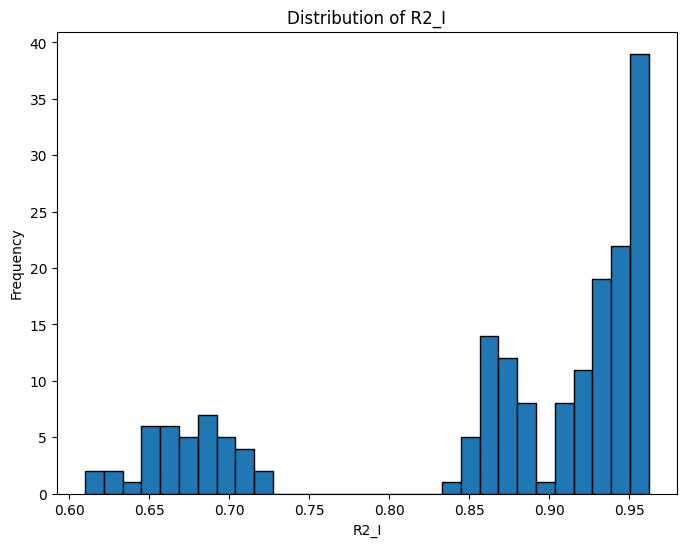

In [16]:
#histogram of R2_I
plt.figure(figsize=(8, 6))
plt.hist(master_df['R2_I'], bins=30, edgecolor='black')
plt.xlabel('R2_I')
plt.ylabel('Frequency')
plt.title('Distribution of R2_I')
plt.show()

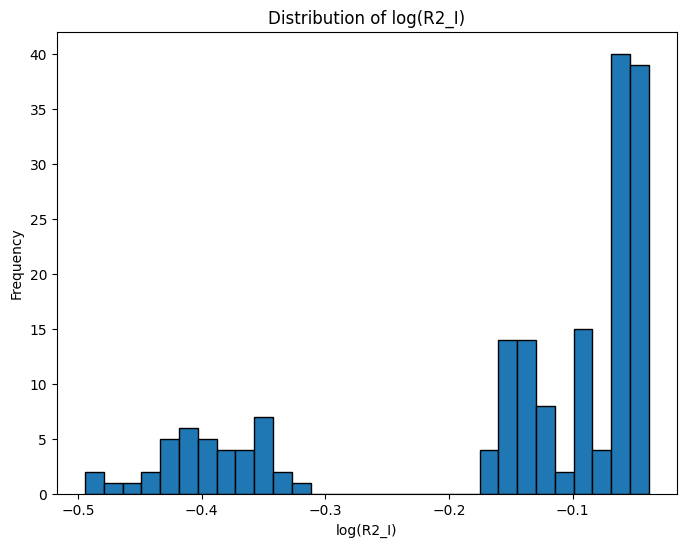

In [17]:
#histogram of R2_I
plt.figure(figsize=(8, 6))
plt.hist(master_df['log_R2_I'], bins=30, edgecolor='black')
plt.xlabel('log(R2_I)')
plt.ylabel('Frequency')
plt.title('Distribution of log(R2_I)')
plt.show()

**Intercept = 7.957 (p < 0.001)**\
The baseline. A model trained far from the threshold (LHS or Random), evaluated on LHS test data, without augmentation predicts 7.96% relative MAE_I on average across replicates. All other coefficients are deviations from this.

**test_strategy[T.MCMC] = +1.131 (p < 0.001)**\
For non-threshold-trained models (in_domain=0), being tested on MCMC test data — the threshold-concentrated set — increases relative MAE_I by 1.13 percentage points compared to being tested on LHS data. This is a crucial finding: threshold-region test data is harder for models not trained near the threshold. The bimodal extinction dynamics near R₀=1 genuinely challenge every model that has not been specifically prepared for them.

**test_strategy[T.UNIFORM_RANDOM] = −0.809 (p = 0.008)**\
Non-threshold-trained models perform 0.81 pp better on Random test data than on LHS test data. Random test data, despite spanning R₀ up to 67, contains many large deterministic epidemics that are structurally easier to predict. LHS test data has more uniform coverage including difficult intermediate regimes.

**in_domain = −1.226 (p < 0.001)**\
The main effect of threshold training. A model trained near the threshold (MCMC, in_domain=1) achieves 1.23 pp lower relative MAE_I than a non-threshold-trained model, when both are tested on LHS data without augmentation. This is your first direct confirmation that proximity of training to the threshold improves accuracy — all else being equal.

**in_domain:test_strategy[T.MCMC] = −2.135 (p < 0.001)**\
This is your dissertation's central finding, expressed as a regression coefficient.
When a threshold-trained model is ALSO tested on threshold data — the MCMC→MCMC condition — there is an additional −2.135 pp accuracy gain beyond what the main effects of training and testing near the threshold predict separately. The total effect of MCMC training when evaluated near the threshold combines three terms:

Main effect of threshold training:     in_domain          = −1.226
Main effect of threshold test:         test = MCMC        = +1.131
Synergistic interaction:               in_domain × MCMC   = −2.135
                                                          ─────────
Net effect vs baseline                                    = −2.230 pp


The interaction is negative and larger in magnitude than either main effect alone. The benefit of training near the threshold is specifically realised in the threshold evaluation domain. This is exactly the scientific claim in my dissertation , and it is now statistically confirmed with p < 0.001.


**in_domain:test_strategy[T.UNIFORM_RANDOM] = +0.937 (p = 0.003)**\
Threshold-trained models (MCMC) are actually 0.937 pp worse on Random test data than the main effects would predict. MCMC models, trained exclusively within R₀ ∈ [0.04, 4.0], struggle more than expected when encountering the extreme R₀ values up to 67 in the Random test set. The specialisation-generalisation tradeoff is statistically confirmed — MCMC gains accuracy in the threshold domain at a measurable cost outside it.

**augmentation = −2.666 (p < 0.001)**\
The single largest coefficient in absolute terms. For non-threshold-trained models tested on LHS data, augmentation reduces relative MAE_I by 2.67 pp. Augmentation is the dominant lever for accuracy improvement across the full parameter space.

**in_domain:augmentation = +1.546 (p < 0.001)**\
Threshold-trained (MCMC) models benefit 1.55 pp less from augmentation than LHS and Random models do. Net augmentation effects per strategy:

LHS / Random:−2.666= −2.666 pp
MCMC:−2.666 + 1.546 = −1.120 pp

This confirms the theoretical argument: MCMC concentration already provides high local density near the threshold. Augmentation compensates for the spatial sparsity that LHS and Random sampling produce in that region, so it helps them more.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


X_vif = X_mat.drop(columns=["Intercept"])

vif_df = pd.DataFrame({
    "predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Rule-of-thumb thresholds
def results(v):
    if v >= 10:  return "High"
    if v >= 5:   return "Moderate"
    return "low"

vif_df["Result"] = vif_df["VIF"].map(results)
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_df.to_string(index=False))





                                            predictor   VIF Result
                                         augmentation 3.750    low
                  train_strategy[T.MCMC]:augmentation 3.250    low
        train_strategy[T.UNIFORM_RANDOM]:augmentation 3.250    low
          C(train_strategy, Treatment("LHS"))[T.MCMC] 2.500    low
C(train_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] 2.500    low
           C(test_strategy, Treatment("LHS"))[T.MCMC] 1.625    low
 C(test_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] 1.625    low


In [19]:
master_df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['replicate_id', 'train_strategy', 'test_strategy', 'augmentation',
       'in_domain', 'n_train_simulations', 'relative_MAE_I', 'R2_I', 'MAE_I',
       'R2_S', 'R2_R', 'R2_overall', 'MAE_S', 'MAE_R', 'RMSE', 'MSE',
       'mean_peak_I', 'n_test_samples', 'model_path', 'training_epoch',
       'source_file', 'peak_I', 'condition_id', 'log_relative_MAE_I',
       'log_R2_I'],
      dtype='object')>

In [20]:
master_df.columns.tolist()

['replicate_id',
 'train_strategy',
 'test_strategy',
 'augmentation',
 'in_domain',
 'n_train_simulations',
 'relative_MAE_I',
 'R2_I',
 'MAE_I',
 'R2_S',
 'R2_R',
 'R2_overall',
 'MAE_S',
 'MAE_R',
 'RMSE',
 'MSE',
 'mean_peak_I',
 'n_test_samples',
 'model_path',
 'training_epoch',
 'source_file',
 'peak_I',
 'condition_id',
 'log_relative_MAE_I',
 'log_R2_I']

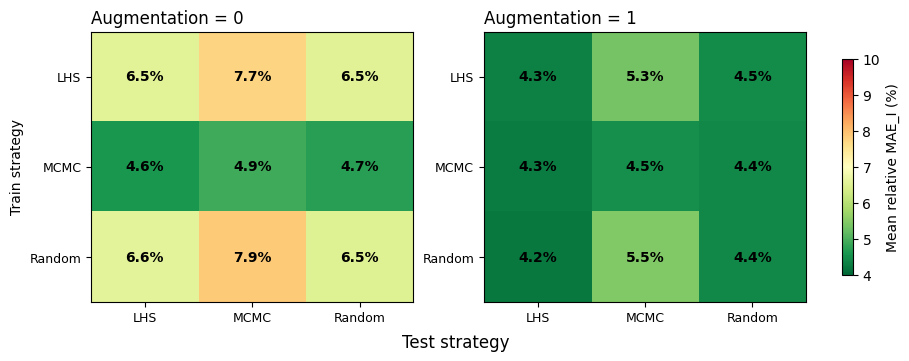

In [21]:

strategies = ["LHS", "MCMC", "UNIFORM_RANDOM"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

for ax, aug in zip(axes, [0, 1]):
    sub = master_df[master_df["augmentation"] == aug]
    matrix = sub.groupby(["train_strategy", "test_strategy"])["relative_MAE_I"].mean().unstack()
    matrix = matrix.loc[strategies, strategies]

    im = ax.imshow(matrix.values, cmap="RdYlGn_r", vmin=4, vmax=10, aspect="auto")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=9)
    ax.set_yticklabels(["LHS", "MCMC", "Random"], fontsize=9)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{matrix.values[i, j]:.1f}%",
                    ha="center", va="center", fontsize=10, fontweight="bold")

    ax.set_title(f"Augmentation = {aug}", loc="left")

axes[0].set_ylabel("Train strategy")
fig.supxlabel("Test strategy")
fig.colorbar(im, ax=axes, label="Mean relative MAE_I (%)", shrink=0.8)
fig.savefig("fig_heatmap.png", dpi=300)


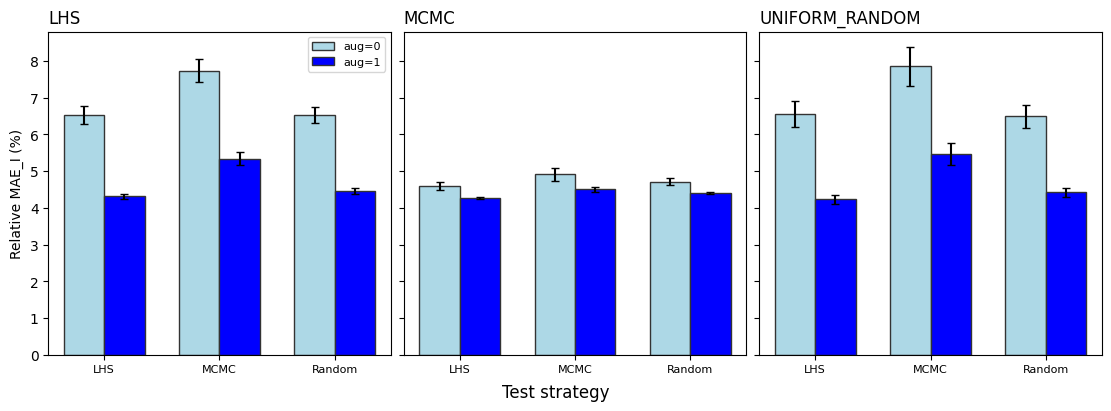

In [22]:
import numpy as np
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(11, 4), constrained_layout=True)
colors = {0: "lightblue", 1: "blue"}
test_order = ["LHS", "MCMC", "UNIFORM_RANDOM"]
x = np.arange(3)
w = 0.35

for ax, train in zip(axes, ["LHS", "MCMC", "UNIFORM_RANDOM"]):
    sub = master_df[master_df["train_strategy"] == train]
    for i, aug in enumerate([0, 1]):
        grouped = sub[sub["augmentation"] == aug].groupby("test_strategy")["relative_MAE_I"]
        means = grouped.mean().reindex(test_order)
        sems  = grouped.sem().reindex(test_order)
        ns    = grouped.size().reindex(test_order)
        ci95  = sems * scipy_stats.t.ppf(0.975, df=ns - 1)  # t-based 95% CI, n=10 replicates -> df=9
        ax.bar(x + i*w, means, w, yerr=ci95, capsize=3,
               color=colors[aug], label=f"aug={aug}", edgecolor="#333")
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=8)
    ax.set_title(train, loc="left")

axes[0].set_ylabel("Relative MAE_I (%)")
axes[0].legend(fontsize=8)
fig.supxlabel("Test strategy")
fig.savefig("fig_bars.png", dpi=300)


**RESULTS**
Note : For interpretation
n=180, 18 conditions (train_strategy x test_strategy x augmentation), replicate models=10 per condition
train_strategy = LHS   (reference training strategy)
test_strategy = LHS    (reference test set)
augmentation = 0       (no augmentation)
Dependent variable: log(relative_MAE_I) -- coefficients below are on the log scale; back-transform with exp() to get percentage-point predictions.
So the intercept is the predicted log(relative MAE_I) for a model trained on LHS data, evaluated on LHS test data, without augmentation. All other coefficients are deviations from this reference on the log scale.

**Intercept = 1.8731 (p < 0.001)** -> exp(1.8731) = 6.51%The baseline. A model trained on LHS data, evaluated on LHS test data, without augmentation predicts 6.51% relative MAE_I on average across replicates. All other coefficients are deviations from this baseline on the log scale; multiply by exp(coef) (or read the %-change below) to get the effect back on the original percentage scale.

**train_strategy[T.MCMC] = -0.3767 (p < 0.001)** -> -31.4%Holding test_strategy=LHS and augmentation=0, training on MCMC (threshold-concentrated) data instead of LHS reduces relative MAE_I by about 31.4% (multiplicatively). This is the strongest single effect in the model: threshold-focused training clearly improves accuracy relative to the LHS baseline.

**train_strategy[T.UNIFORM_RANDOM] = +0.0032 (p = 0.836)** -> +0.3%, not significantTraining on UNIFORM_RANDOM data instead of LHS makes essentially no difference (holding test=LHS, aug=0). LHS and Random are statistically indistinguishable as training strategies at this baseline; the only training strategy that matters is MCMC.

**test_strategy[T.MCMC] = +0.1554 (p < 0.001)** -> +16.8%For LHS-trained models, being evaluated on MCMC (threshold-concentrated) test data increases relative MAE_I by about 16.8% compared to being evaluated on LHS test data. Threshold-region test data is harder for models not trained near the threshold.

**test_strategy[T.UNIFORM_RANDOM] = +0.0206 (p = 0.060)** -> +2.1%, marginalFor LHS-trained models, testing on Random data is about 2.1% worse than testing on LHS data -- a small effect that only just misses the conventional 0.05 threshold.

**augmentation = -0.3883 (p < 0.001)** -> -32.2% (for LHS-trained models)The single largest coefficient in absolute terms. For LHS-trained models tested on LHS data, augmentation reduces relative MAE_I by about 32.2%. Augmentation is the dominant lever for accuracy improvement at the reference condition.

**train_strategy[T.MCMC]:augmentation = +0.3131 (p < 0.001)**This interaction largely cancels the main augmentation effect for MCMC-trained models. Net augmentation effect per training strategy:

- LHS:            -0.3883                  -> -32.2%
- MCMC:           -0.3883 + 0.3131 = -0.0752 -> -7.2%
- UNIFORM_RANDOM: -0.3883 - 0.0058 = -0.3941 -> -32.6%

MCMC concentration already provides high local sample density near the threshold, so augmentation compensates for spatial sparsity that LHS and Random sampling suffer from in that region -- it therefore helps LHS and Random much more than it helps MCMC.

**train_strategy[T.UNIFORM_RANDOM]:augmentation = -0.0058 (p = 0.792)**Not significant -- the augmentation benefit for UNIFORM_RANDOM-trained models is statistically indistinguishable from the LHS baseline (both around -32%).

Condition                          Prediction (%)
--------------------------------------------------------------
LHS -> LHS,             aug=0:  exp(1.8731)                                    = 6.508
LHS -> LHS,             aug=1:  exp(1.8731 - 0.3883)                           = 4.414
LHS -> MCMC,             aug=0:  exp(1.8731 + 0.1554)                          = 7.603
LHS -> MCMC,             aug=1:  exp(1.8731 + 0.1554 - 0.3883)                 = 5.156
Random -> Random,       aug=0:  exp(1.8731 + 0.0032 + 0.0206)                  = 6.665
Random -> MCMC,          aug=0:  exp(1.8731 + 0.0032 + 0.1554)                 = 7.627
MCMC -> LHS,             aug=0:  exp(1.8731 - 0.3767)                          = 4.466
MCMC -> LHS,             aug=1:  exp(1.8731 - 0.3767 - 0.3883 + 0.3131)        = 4.142
MCMC -> MCMC,            aug=0:  exp(1.8731 - 0.3767 + 0.1554)                 = 5.216
MCMC -> MCMC,            aug=1:  exp(1.8731 - 0.3767 + 0.1554 - 0.3883 + 0.3131) = 4.838
MCMC -> Random,          aug=0:  exp(1.8731 - 0.3767 + 0.0206)                 = 4.559

Each row exponentiates the sum of the relevant log-scale coefficients (Intercept + train effect + test effect + augmentation slope for that train strategy) back onto the original relative_MAE_I (%) scale.

**Hypothesis Testing**

Hypothesis 1 -- MCMC (threshold) training improves accuracy vs LHSH0: beta_train:MCMC = 0H1: beta_train:MCMC < 0   (one-tailed, direction pre-specified)Test: t = -24.386, p < 0.001. Reject H0.

Hypothesis 2 -- UNIFORM_RANDOM training differs from LHSH0: beta_train:UNIFORM_RANDOM = 0H1: beta_train:UNIFORM_RANDOM != 0   (two-tailed, direction not pre-specified)Test: t = 0.207, p = 0.836. Fail to reject H0 -- no evidence LHS and Random differ as training strategies.

Hypothesis 3 -- Augmentation improves accuracy (LHS baseline)H0: beta_augmentation = 0H1: beta_augmentation < 0   (one-tailed)Test: t = -25.141, p < 0.001. Reject H0.

Hypothesis 4 -- The augmentation benefit differs for MCMC-trained modelsH0: beta_train:MCMC:augmentation = 0H1: beta_train:MCMC:augmentation != 0   (two-tailed, direction less certain)Test: t = 14.332, p < 0.001. Reject H0 -- the positive sign means MCMC-trained models gain markedly less from augmentation than LHS/Random-trained models (net -7.2% vs approx -32%).

Hypothesis 5 -- Threshold (MCMC) test data is harder for non-threshold-trained modelsH0: beta_test:MCMC = 0H1: beta_test:MCMC > 0   (one-tailed, direction pre-specified)Test: t = 14.225, p < 0.001. Reject H0.

In [23]:
from statsmodels.stats.anova import anova_lm
import numpy as np

def scalar(value):
    """Return a Python float from statsmodels scalars or 1x1 arrays."""
    return float(np.asarray(value).squeeze())


# Joint test 1: Does train strategy matter at all?
# H₀: β_train:LHS = β_train:MCMC = 0
restrictions_train = (
    'C(train_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] = 0, '
    'C(train_strategy, Treatment("LHS"))[T.MCMC] = 0'
)
f_test_train = ols_model.f_test(restrictions_train)
print("Joint test — train strategy effects:")
print(f"  F = {scalar(f_test_train.fvalue):.3f}")
print(f"  p = {f_test_train.pvalue:.4e}")

# Joint test 2: Does test strategy matter at all?
# H₀: β_test:LHS = β_test:MCMC = 0
restrictions_test = (
    'C(test_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] = 0, '
    'C(test_strategy, Treatment("LHS"))[T.MCMC] = 0'
)
f_test_strategy = ols_model.f_test(restrictions_test)
print("\nJoint test — test strategy effects:")
print(f"  F = {scalar(f_test_strategy.fvalue):.3f}")
print(f"  p = {f_test_strategy.pvalue:.4e}")

# Joint test 3: Does augmentation matter?
# H₀: β_augmentation = 0 (single restriction, equivalent to the t-test)
restrictions_aug = 'augmentation = 0'
f_test_aug = ols_model.f_test(restrictions_aug)
print("\nJoint test — augmentation effect:")
print(f"  F = {scalar(f_test_aug.fvalue):.3f}")
print(f"  p = {f_test_aug.pvalue:.4e}")


Joint test — train strategy effects:
  F = 399.837
  p = 2.1316e-65

Joint test — test strategy effects:
  F = 119.354
  p = 3.1014e-33

Joint test — augmentation effect:
  F = 632.070
  p = 1.7191e-59


In [24]:
import numpy as np
import pandas as pd

def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_sd = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_sd

def d_label(d):
    ad = abs(d)
    if ad >= 0.8:  return "large"
    if ad >= 0.5:  return "medium"
    if ad >= 0.2:  return "small"
    return "negligible"


# Cohen's d — Pairwise train_strategy comparisons

strategies = ["LHS", "MCMC", "UNIFORM_RANDOM"]
labels_map = {"LHS": "LHS", "MCMC": "MCMC", "UNIFORM_RANDOM": "Random"}

train_groups = {s: master_df.loc[master_df["train_strategy"] == s, "relative_MAE_I"].values
                for s in strategies}

print("Cohen's d — Pairwise train_strategy comparisons")
print(f"   {'Pair':<22}  {'Mean A (%)':>10}  {'Mean B (%)':>10}  {'Δ (pp)':>7}  {'d':>7}  {'Size'}")
for i, s1 in enumerate(strategies):
    for s2 in strategies[i+1:]:
        g1, g2 = train_groups[s1], train_groups[s2]
        d_val  = cohen_d(g1, g2)
        pair   = f"{labels_map[s1]} vs {labels_map[s2]}"
        print(f"   {pair:<22}  {g1.mean():>10.3f}  {g2.mean():>10.3f}  "
              f"{g1.mean()-g2.mean():>+7.3f}  {d_val:>+7.3f}  {d_label(d_val)}")


# Cohen's d — Pairwise test_strategy comparisons

test_groups = {s: master_df.loc[master_df["test_strategy"] == s, "relative_MAE_I"].values
               for s in strategies}

print("\nCohen's d — Pairwise test_strategy comparisons")
print(f"   {'Pair':<22}  {'Mean A (%)':>10}  {'Mean B (%)':>10}  {'Δ (pp)':>7}  {'d':>7}  {'Size'}")
for i, s1 in enumerate(strategies):
    for s2 in strategies[i+1:]:
        g1, g2 = test_groups[s1], test_groups[s2]
        d_val  = cohen_d(g1, g2)
        pair   = f"{labels_map[s1]} vs {labels_map[s2]}"
        print(f"   {pair:<22}  {g1.mean():>10.3f}  {g2.mean():>10.3f}  "
              f"{g1.mean()-g2.mean():>+7.3f}  {d_val:>+7.3f}  {d_label(d_val)}")


# Cohen's d — Augmentation (0 vs 1)

aug0 = master_df.loc[master_df["augmentation"] == 0, "relative_MAE_I"].values
aug1 = master_df.loc[master_df["augmentation"] == 1, "relative_MAE_I"].values
d_aug = cohen_d(aug0, aug1)

print("\nCohen's d — Augmentation (0 vs 1)")
print(f"   {'Pair':<22}  {'Mean A (%)':>10}  {'Mean B (%)':>10}  {'Δ (pp)':>7}  {'d':>7}  {'Size'}")
print(f"   {'aug=0 vs aug=1':<22}  {aug0.mean():>10.3f}  {aug1.mean():>10.3f}  "
      f"{aug0.mean()-aug1.mean():>+7.3f}  {d_aug:>+7.3f}  {d_label(d_aug)}")


Cohen's d — Pairwise train_strategy comparisons
   Pair                    Mean A (%)  Mean B (%)   Δ (pp)        d  Size
   LHS vs MCMC                  5.819       4.567   +1.251   +1.371  large
   LHS vs Random                5.819       5.837   -0.019   -0.014  negligible
   MCMC vs Random               4.567       5.837   -1.270   -1.305  large

Cohen's d — Pairwise test_strategy comparisons
   Pair                    Mean A (%)  Mean B (%)   Δ (pp)        d  Size
   LHS vs MCMC                  5.084       5.967   -0.883   -0.707  medium
   LHS vs Random                5.084       5.171   -0.087   -0.083  negligible
   MCMC vs Random               5.967       5.171   +0.796   +0.658  medium

Cohen's d — Augmentation (0 vs 1)
   Pair                    Mean A (%)  Mean B (%)   Δ (pp)        d  Size
   aug=0 vs aug=1               6.214       4.601   +1.614   +1.741  large


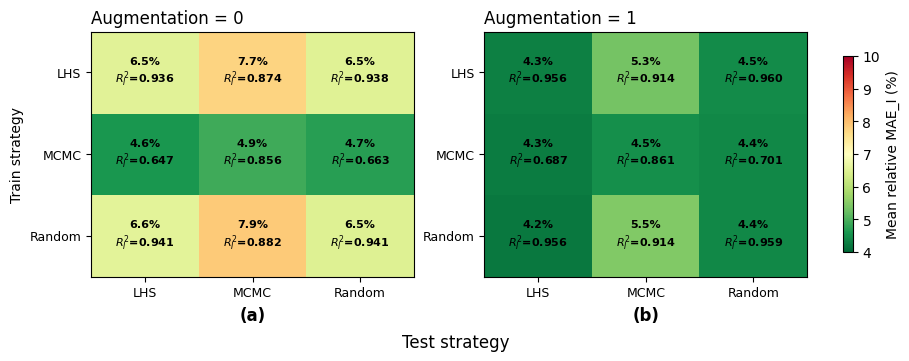

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

strategies = ["LHS", "MCMC", "UNIFORM_RANDOM"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

for idx, (ax, aug) in enumerate(zip(axes, [0, 1])):
    sub = master_df[master_df["augmentation"] == aug]
    matrix = sub.groupby(["train_strategy", "test_strategy"])["relative_MAE_I"].mean().unstack()
    matrix = matrix.loc[strategies, strategies]

    r2_matrix = sub.groupby(["train_strategy", "test_strategy"])["R2_I"].mean().unstack()
    r2_matrix = r2_matrix.loc[strategies, strategies]

    im = ax.imshow(matrix.values, cmap="RdYlGn_r", vmin=4, vmax=10, aspect="auto")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=9)
    ax.set_yticklabels(["LHS", "MCMC", "Random"], fontsize=9)

    for i in range(3):
        for j in range(3):
            ax.text(j, i,
                    f"{matrix.values[i, j]:.1f}%\n$R^2_I$={r2_matrix.values[i, j]:.3f}",
                    ha="center", va="center", fontsize=8, fontweight="bold")

    ax.set_title(f"Augmentation = {aug}", loc="left")
    ax.text(0.5, -0.18, f"({chr(97 + idx)})", transform=ax.transAxes,
            fontsize=12, fontweight="bold", ha="center")

axes[0].set_ylabel("Train strategy")
fig.supxlabel("Test strategy")
fig.colorbar(im, ax=axes, label="Mean relative MAE_I (%)", shrink=0.8)
fig.savefig("fig_heatmap.png", dpi=300)

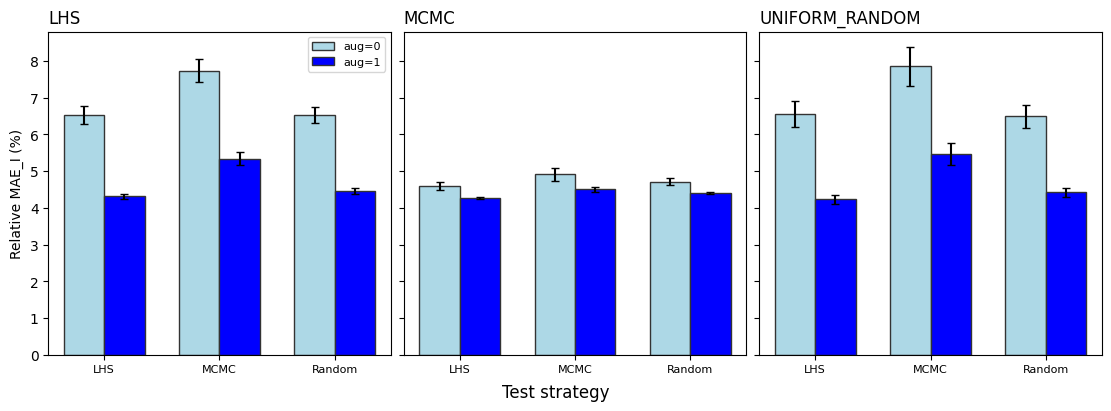

In [26]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(11, 4), constrained_layout=True)
colors = {0: "lightblue", 1: "blue"}
test_order = ["LHS", "MCMC", "UNIFORM_RANDOM"]
x = np.arange(3)
w = 0.35

for ax, train in zip(axes, ["LHS", "MCMC", "UNIFORM_RANDOM"]):
    sub = master_df[master_df["train_strategy"] == train]
    for i, aug in enumerate([0, 1]):
        grouped = sub[sub["augmentation"] == aug].groupby("test_strategy")["relative_MAE_I"]
        means = grouped.mean().reindex(test_order)
        sems  = grouped.sem().reindex(test_order)
        ns    = grouped.size().reindex(test_order)
        ci95  = sems * scipy_stats.t.ppf(0.975, df=ns - 1)  # t-based 95% CI, n=10 replicates -> df=9
        ax.bar(x + i*w, means, w, yerr=ci95, capsize=3,
               color=colors[aug], label=f"aug={aug}", edgecolor="#333")
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=8)
    ax.set_title(train, loc="left")

axes[0].set_ylabel("Relative MAE_I (%)")
axes[0].legend(fontsize=8)
fig.supxlabel("Test strategy")
fig.savefig("fig_bars.png", dpi=300)


In [27]:
train = "UNIFORM_RANDOM"  # explicit choice for this scratch check (previously an implicit loop leftover)
sub = master_df[master_df["train_strategy"] == train]
per_rep = sub.groupby(["augmentation", "replicate_id"])["relative_MAE_I"].mean()
print(per_rep.head(30))

augmentation  replicate_id
0             1               6.194267
              2               6.384967
              3               6.777133
              4               6.679567
              5               7.807767
              6               6.939567
              7               7.175433
              8               7.214333
              9               6.685500
              10              7.842133
1             1               4.502067
              2               4.589333
              3               4.750733
              4               4.898200
              5               5.303633
              6               4.657400
              7               4.679633
              8               4.508233
              9               4.420800
              10              4.733633
Name: relative_MAE_I, dtype: float64


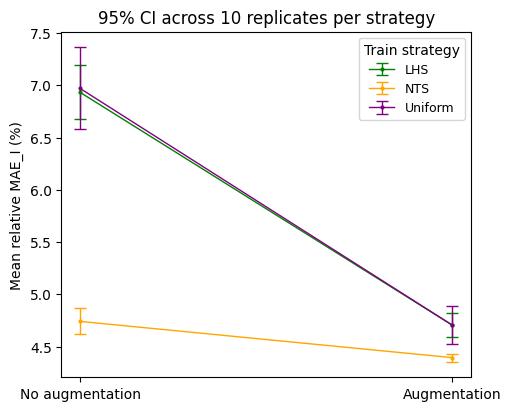

In [28]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
palette = {"LHS": "green", "MCMC": "orange", "UNIFORM_RANDOM": "purple"}  # tab10 colors, matched lightness so none dominates when lines overlap
label_map = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform"}  # display names only -- keys must match train_strategy values

for train, color in palette.items():
    sub = master_df[master_df["train_strategy"] == train]
    assert not sub.empty, f"no rows found for train_strategy={train!r}"
    per_rep = sub.groupby(["augmentation", "replicate_id"])["relative_MAE_I"].mean()
    grouped = per_rep.groupby("augmentation")
    means = grouped.mean().reindex([0, 1])
    sems = grouped.sem().reindex([0, 1])
    n = grouped.size().reindex([0, 1])
    ci95 = sems * stats.t.ppf(0.975, df=n - 1)  # t-based 95% CI, n=10 replicates -> df=9 because my n is small
    ax.errorbar([0, 1], means.values, yerr=ci95.values, fmt="o-", color=color,
                label=label_map[train], lw=1, ms=2, capsize=4, elinewidth=1)

ax.set_xticks([0, 1])
ax.set_xticklabels(["No augmentation", "Augmentation"])
ax.set_ylabel("Mean relative MAE_I (%)")
ax.legend(title="Train strategy", fontsize=9)
ax.set_title("95% CI across 10 replicates per strategy")
fig.savefig("fig_interaction_ci95.png", dpi=900)


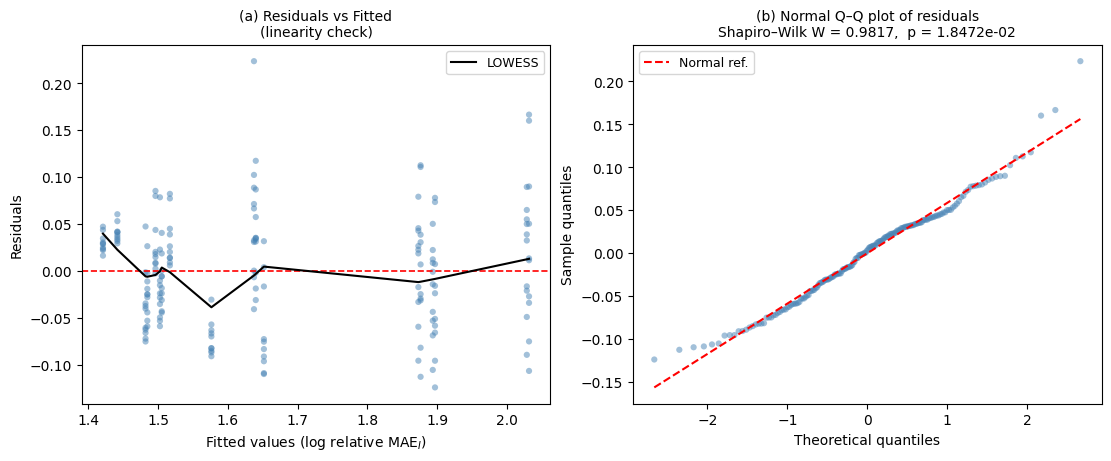

Shapiro–Wilk: W = 0.9817,  p = 1.8472e-02
Residual skewness : 0.3521
Residual kurtosis : 0.5208  (excess)


In [29]:

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as scipy_stats
from statsmodels.graphics.gofplots import qqplot

fitted  = ols_model.fittedvalues
resid   = ols_model.resid
std_resid = resid / resid.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

# ── (a) Residuals vs Fitted — linearity check ──────────────────────────────
ax = axes[0]
ax.scatter(fitted, resid, alpha=0.5, s=20, color="steelblue", edgecolors="none")
ax.axhline(0, color="red", lw=1.2, ls="--")

# LOWESS smoother to reveal any systematic curvature
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(resid, fitted, frac=0.4)
ax.plot(smooth[:, 0], smooth[:, 1], color="black", lw=1.5, label="LOWESS")

ax.set_xlabel("Fitted values (log relative MAE$_I$)", fontsize=10)
ax.set_ylabel("Residuals", fontsize=10)
ax.set_title("(a) Residuals vs Fitted\n(linearity check)", fontsize=10)
ax.legend(fontsize=9)

# ── (b) Normal Q–Q plot — normality check ─────────────────────────────────
ax = axes[1]
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(resid, dist="norm")
ax.scatter(osm, osr, alpha=0.5, s=20, color="steelblue", edgecolors="none")
ax.plot(osm, slope * np.array(osm) + intercept, color="red", lw=1.5, ls="--", label="Normal ref.")

# Shapiro–Wilk test (n ≤ 5000)
sw_stat, sw_p = scipy_stats.shapiro(resid)
ax.set_xlabel("Theoretical quantiles", fontsize=10)
ax.set_ylabel("Sample quantiles", fontsize=10)
ax.set_title(
    f"(b) Normal Q–Q plot of residuals\n"
    f"Shapiro–Wilk W = {sw_stat:.4f},  p = {sw_p:.4e}",
    fontsize=10,
)
ax.legend(fontsize=9)

fig.savefig("fig_diagnostics_linearity_normality.png", dpi=300)
plt.show()

print(f"Shapiro–Wilk: W = {sw_stat:.4f},  p = {sw_p:.4e}")
print(f"Residual skewness : {scipy_stats.skew(resid):.4f}")
print(f"Residual kurtosis : {scipy_stats.kurtosis(resid):.4f}  (excess)")


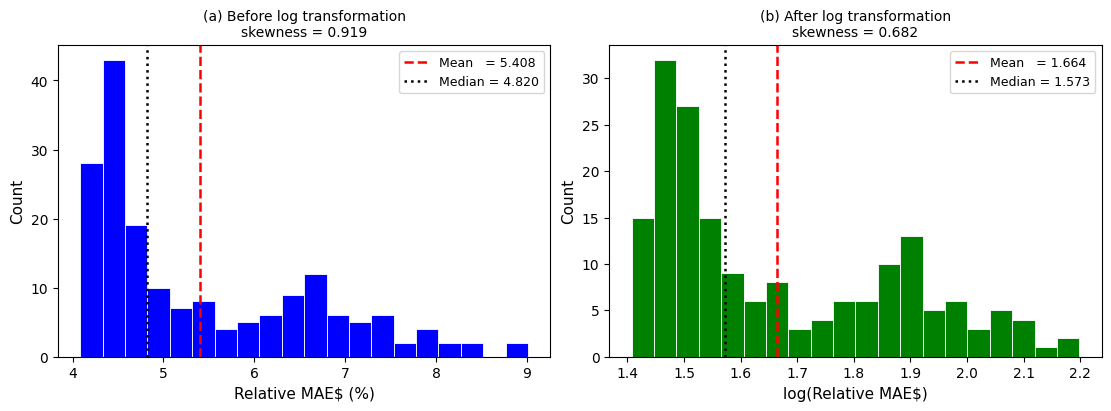

Raw   skewness=0.9189  mean=5.4076  median=4.8197  std=1.2285
Log   skewness=0.6816  mean=1.6643  median=1.5727  std=0.2126


In [30]:
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt

raw = master_df["relative_MAE_I"]
log = master_df["log_relative_MAE_I"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for ax, y, xlabel, title_label, colour in zip(
    axes,
    [raw, log],
    ["Relative MAE$ (%)", "log(Relative MAE$)"],
    ["(a) Before log transformation", "(b) After log transformation"],
    ["blue", "green"],
):
    skew   = scipy_stats.skew(y)
    mean   = y.mean()
    median = y.median()

    ax.hist(y, bins=20, color=colour, edgecolor="white", linewidth=0.6)
    ax.axvline(mean,   color="red",   lw=1.8, ls="--", label=f"Mean   = {mean:.3f}")
    ax.axvline(median, color="black", lw=1.8, ls=":",  label=f"Median = {median:.3f}")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{title_label}\nskewness = {skew:.3f}", fontsize=10)
    ax.legend(fontsize=9)

fig.savefig("fig_histogram_distribution_comparison.png", dpi=300)
plt.show()

for label, y in [("Raw", raw), ("Log", log)]:
    print(f"{label:4s}  skewness={scipy_stats.skew(y):.4f}  "
          f"mean={y.mean():.4f}  median={y.median():.4f}  std={y.std():.4f}")


1. CLUSTER COUNT & SIZE
   Number of clusters (G)          : 18
   Observations per cluster (n_g)  : [10]
   Total observations (N)          : 180

   Rule-of-thumb verdict (G >= 30 preferred): TOO FEW — cluster-robust SEs may be severely biased; use wild bootstrap

2. INTRA-CLUSTER CORRELATION (ICC)
   ICC = 0.3080
   Interpretation:
     High ICC — strong within-cluster correlation; cluster-robust SEs essential
   Design effect (DEFF = 1 + (n_g-1)*ICC) = 3.772
   Effective N = 47.7  (vs nominal N = 180)

3. MEAN RESIDUALS BY CLUSTER
   (non-zero means → cluster absorbs systematic variation)
                   condition_id      mean      std  n
                    MCMC_MCMC_1 -0.071190 0.018293 10
                    MCMC_MCMC_0 -0.061538 0.049905 10
           UNIFORM_RANDOM_LHS_1 -0.039982 0.038023 10
UNIFORM_RANDOM_UNIFORM_RANDOM_0 -0.027322 0.066297 10
                      LHS_LHS_1 -0.023762 0.025152 10
           LHS_UNIFORM_RANDOM_0 -0.018984 0.047453 10
UNIFORM_RANDOM_UNIFORM

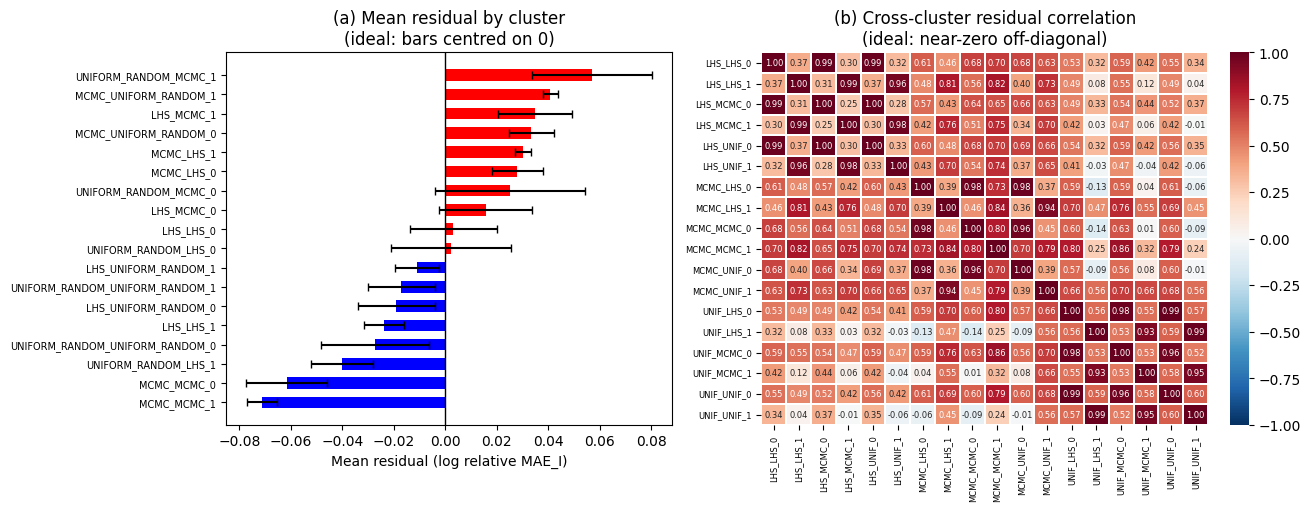

In [31]:


# Cluster Adequacy & Independence Diagnostics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as scipy_stats
from statsmodels.stats.inter_rater import fleiss_kappa  # not used but keep imports clean

# ── 0. Attach residuals to the dataframe ────────────────────────────────────
master_df["resid"] = ols_model.resid.values

cluster_col = "condition_id"
G = master_df[cluster_col].nunique()
cluster_sizes = master_df.groupby(cluster_col).size()

print("=" * 60)
print("1. CLUSTER COUNT & SIZE")
print("=" * 60)
print(f"   Number of clusters (G)          : {G}")
print(f"   Observations per cluster (n_g)  : {cluster_sizes.unique().tolist()}")
print(f"   Total observations (N)          : {len(master_df)}")
print()
# Rule-of-thumb thresholds (Cameron & Miller 2015; MacKinnon & Webb 2017)
if G < 20:
    verdict = "TOO FEW — cluster-robust SEs may be severely biased; use wild bootstrap"
elif G < 30:
    verdict = "BORDERLINE — supplement with wild cluster bootstrap"
elif G < 50:
    verdict = "ADEQUATE for most applications"
else:
    verdict = "SUFFICIENT"
print(f"   Rule-of-thumb verdict (G >= 30 preferred): {verdict}")
print()

# ── 1. Intra-cluster Correlation (ICC) ─────────────────────────────────────
print("=" * 60)
print("2. INTRA-CLUSTER CORRELATION (ICC)")
print("=" * 60)
# ICC = between-cluster variance / total variance (from one-way ANOVA decomposition)
grand_mean = master_df["resid"].mean()
cluster_means = master_df.groupby(cluster_col)["resid"].mean()
n_per = cluster_sizes.mean()

SS_between = sum(cluster_sizes[g] * (cluster_means[g] - grand_mean) ** 2
                 for g in cluster_means.index)
SS_within  = master_df.groupby(cluster_col)["resid"].apply(lambda x: ((x - x.mean()) ** 2).sum()).sum()

MS_between = SS_between / (G - 1)
MS_within  = SS_within  / (len(master_df) - G)

icc = (MS_between - MS_within) / (MS_between + (n_per - 1) * MS_within)
print(f"   ICC = {icc:.4f}")
print(f"   Interpretation:")
if icc < 0.05:
    print("     Low ICC — clustering has minimal effect; OLS SEs likely adequate")
elif icc < 0.20:
    print("     Moderate ICC — clustering matters; cluster-robust SEs appropriate")
else:
    print("     High ICC — strong within-cluster correlation; cluster-robust SEs essential")

# Design effect (DEFF) — how much variance inflation clustering causes
deff = 1 + (n_per - 1) * icc
print(f"   Design effect (DEFF = 1 + (n_g-1)*ICC) = {deff:.3f}")
print(f"   Effective N = {len(master_df) / deff:.1f}  (vs nominal N = {len(master_df)})")
print()

# ── 2. Between-cluster residual pattern (heatmap) ──────────────────────────
print("=" * 60)
print("3. MEAN RESIDUALS BY CLUSTER")
print("   (non-zero means → cluster absorbs systematic variation)")
print("=" * 60)
clust_resid = (master_df.groupby(cluster_col)["resid"]
               .agg(mean="mean", std="std", n="count")
               .reset_index()
               .sort_values("mean"))
print(clust_resid.to_string(index=False))
print()

# ── 3. Cross-cluster residual correlation ──────────────────────────────────
print("=" * 60)
print("4. CROSS-CLUSTER RESIDUAL CORRELATION")
print("   (off-diagonal values >> 0 indicate cluster non-independence)")
print("=" * 60)

# Pivot: rows = replicates, cols = clusters
resid_wide = master_df.pivot_table(
    index="replicate_id", columns=cluster_col, values="resid", aggfunc="mean"
)
corr_matrix = resid_wide.corr()

# Flag strong correlations (|r| > 0.5) between clusters sharing the same train or test strategy
strong = [(i, j, corr_matrix.loc[i, j])
          for i in corr_matrix.index for j in corr_matrix.columns
          if i < j and abs(corr_matrix.loc[i, j]) > 0.5]
if strong:
    print(f"   Cluster pairs with |r| > 0.5 (potential non-independence):")
    for i, j, r in sorted(strong, key=lambda x: -abs(x[2])):
        print(f"     {i}  ↔  {j}   r = {r:.3f}")
else:
    print("   No cluster pairs with |r| > 0.5 detected.")
print()

# ── 4. Wild Cluster Bootstrap p-values (Webb 6-point weights) ──────────────
print("=" * 60)
print("5. WILD CLUSTER BOOTSTRAP (B=999, Webb weights)")
print("   Robust alternative to asymptotic cluster-robust SEs when G is small")
print("=" * 60)

np.random.seed(42)
B = 999
clusters = master_df[cluster_col].unique()
X_np = X_mat.values
y_np = y_mat.values.ravel()
beta_hat = ols_model.params.values
resid_np = ols_model.resid.values
# Webb 6-point weights
webb_weights = np.array([-np.sqrt(3/2), -1, -np.sqrt(1/2),
                          np.sqrt(1/2),  1,  np.sqrt(3/2)])

boot_coefs = np.zeros((B, len(beta_hat)))
for b in range(B):
    w = np.ones(len(master_df))
    for g in clusters:
        mask = master_df[cluster_col] == g
        w[mask] = np.random.choice(webb_weights)
    y_star = X_np @ beta_hat + resid_np * w
    beta_star = np.linalg.lstsq(X_np, y_star, rcond=None)[0]
    boot_coefs[b] = beta_star

# Bootstrap p-values (two-tailed, imposing H₀ by centering at beta_hat)
coef_names_boot = ols_model.model.exog_names
boot_p = {}
for k, name in enumerate(coef_names_boot):
    t_obs = model_robust.tvalues[k]
    t_boot = (boot_coefs[:, k] - beta_hat[k]) / (boot_coefs[:, k].std() + 1e-12)
    boot_p[name] = np.mean(np.abs(t_boot) >= np.abs(t_obs))

boot_df = pd.DataFrame({
    "Coefficient": coef_names_boot,
    "Asymptotic p": [float(model_robust.pvalues[k]) for k, n in enumerate(coef_names_boot)],
    "Bootstrap p":  [boot_p[n] for n in coef_names_boot],
})
boot_df["Conclusion"] = boot_df.apply(
    lambda r: "Agree" if (r["Asymptotic p"] < 0.05) == (r["Bootstrap p"] < 0.05) else "DISAGREE",
    axis=1
)
print(boot_df.to_string(index=False))
print()

# 5. Figures 
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# (a) Mean residual per cluster with 1 SD error bars
ax = axes[0]
colors_bar = ["red" if v > 0 else "blue" for v in clust_resid["mean"]]
ax.barh(clust_resid[cluster_col], clust_resid["mean"],
        xerr=clust_resid["std"] / np.sqrt(clust_resid["n"]),
        color=colors_bar, edgecolor="none", height=0.6, capsize=3)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Mean residual (log relative MAE_I)")
ax.set_title("(a) Mean residual by cluster\n(ideal: bars centred on 0)")
ax.tick_params(axis="y", labelsize=7)

# (b) Cross-cluster correlation heatmap
ax = axes[1]
short_labels = [c.replace("UNIFORM_RANDOM", "UNIF") for c in corr_matrix.columns]
sns.heatmap(
    corr_matrix.values, ax=ax,
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    linewidths=0.3,
)
ax.set_title("(b) Cross-cluster residual correlation\n(ideal: near-zero off-diagonal)")
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.tick_params(axis="y", rotation=0,  labelsize=6)

fig.savefig("fig_cluster_diagnostics.png", dpi=300)
plt.show()

In [32]:
model_means = (
    master_df
    .groupby(["train_strategy", "replicate_id"])["relative_MAE_I"]
    .mean()
    .reset_index()
)

def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_sd = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_sd

lhs  = model_means.loc[model_means["train_strategy"]=="LHS",           "relative_MAE_I"]
mcmc = model_means.loc[model_means["train_strategy"]=="MCMC",          "relative_MAE_I"]
rand = model_means.loc[model_means["train_strategy"]=="UNIFORM_RANDOM","relative_MAE_I"]

print(f"LHS  mean = {lhs.mean():.3f}%   (n={len(lhs)})")
print(f"MCMC mean = {mcmc.mean():.3f}%   (n={len(mcmc)})")
print(f"Rand mean = {rand.mean():.3f}%   (n={len(rand)})")
print()
print(f"LHS  vs MCMC  d = {cohen_d(lhs,  mcmc):.3f}")
print(f"LHS  vs Rand  d = {cohen_d(lhs,  rand):.3f}")
print(f"MCMC vs Rand  d = {cohen_d(mcmc, rand):.3f}")

LHS  mean = 5.819%   (n=10)
MCMC mean = 4.567%   (n=10)
Rand mean = 5.837%   (n=10)

LHS  vs MCMC  d = 7.295
LHS  vs Rand  d = -0.062
MCMC vs Rand  d = -4.763


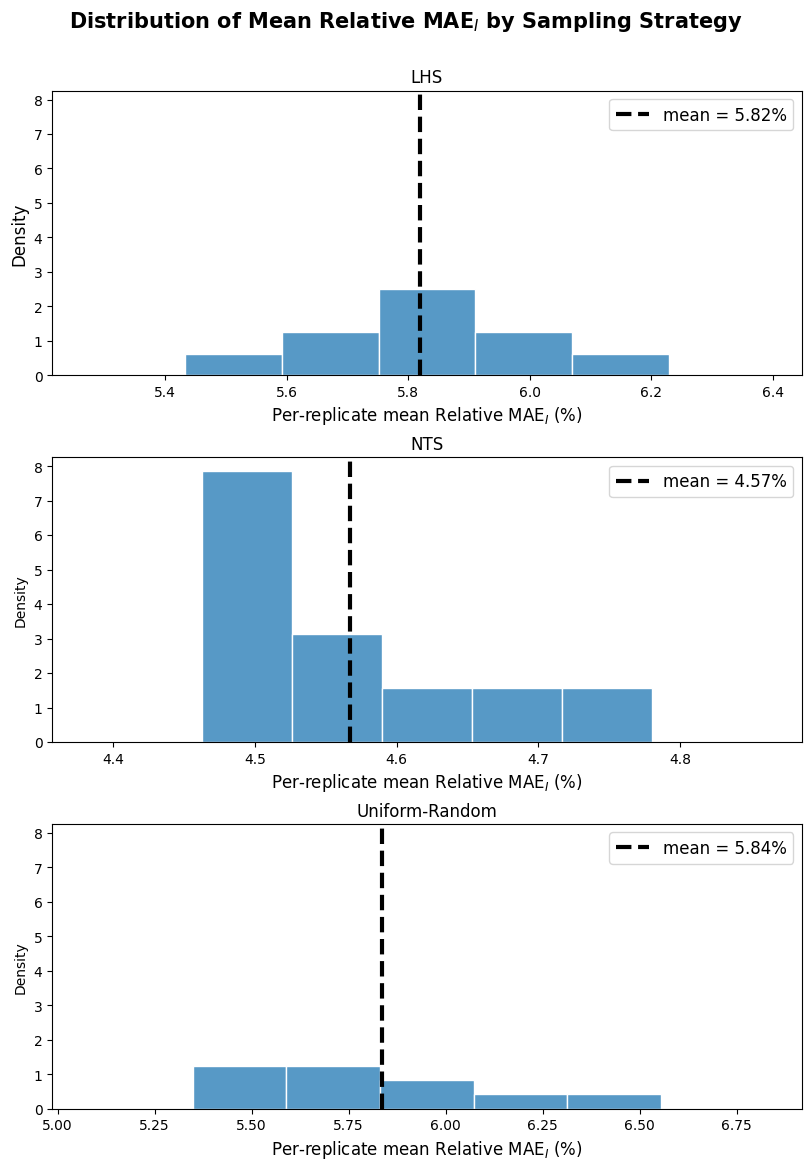

LHS             mean=5.819%  median=5.792%  std=0.218%  n=10
MCMC            mean=4.567%  median=4.524%  std=0.106%  n=10
UNIFORM_RANDOM  mean=5.837%  median=5.794%  std=0.362%  n=10


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

strategy_order  = ["LHS", "MCMC", "UNIFORM_RANDOM"]
strategy_labels = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform-Random"}
palette = {strategy_labels[s]: c for s, c in zip(strategy_order, ["tab:blue", "tab:blue", "tab:blue"])}

fig, axes = plt.subplots(3, 1, figsize=(8, 11), constrained_layout=True, sharex=False, sharey=True)

for ax, strategy in zip(axes, strategy_order):
    vals  = model_means.loc[model_means["train_strategy"] == strategy, "relative_MAE_I"]
    color = palette[strategy_labels[strategy]]

    sns.histplot(vals, stat="density", color=color, edgecolor="white", ax=ax)
    ax.axvline(vals.mean(), color="black", lw=3, ls="--", label=f"mean = {vals.mean():.2f}%")

    ax.set_title(strategy_labels[strategy], fontsize=12)

    ax.set_xlim(vals.min() - vals.std(), vals.max() + vals.std())
    ax.set_xlabel("Per-replicate mean Relative MAE$_I$ (%)", fontsize=12)
    ax.legend(fontsize=12)

axes[0].set_ylabel("Density", fontsize=12)
fig.suptitle("Distribution of Mean Relative MAE$_I$ by Sampling Strategy", fontsize=15, fontweight="bold", y=1.05)

fig.savefig("fig_mean_relative_mae_by_strategy.png", dpi=900)
plt.show()

for strategy in strategy_order:
    vals = model_means.loc[model_means["train_strategy"] == strategy, "relative_MAE_I"]
    print(f"{strategy:15s} mean={vals.mean():.3f}%  median={vals.median():.3f}%  std={vals.std():.3f}%  n={len(vals)}")


Robustness / consistency across replicates (lower CV = more consistent retrains)
                 mean    std   n  cv_pct
train_strategy                          
LHS             5.819  0.218  10   3.754
MCMC            4.567  0.106  10   2.311
UNIFORM_RANDOM  5.837  0.362  10   6.202


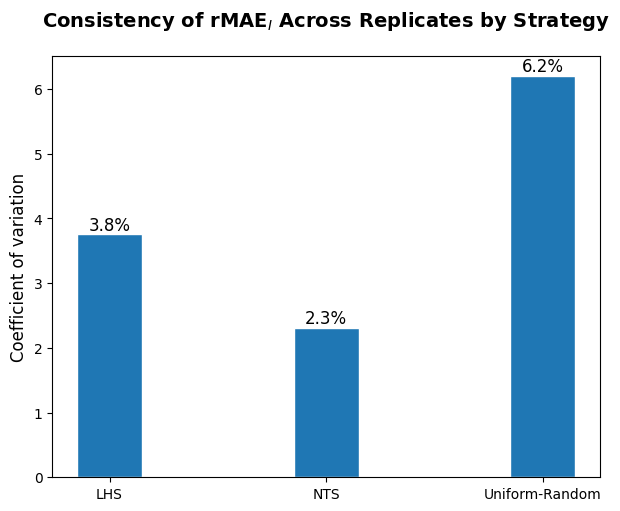

In [34]:
import matplotlib.pyplot as plt

strategy_order  = ["LHS", "MCMC", "UNIFORM_RANDOM"]
strategy_labels = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform-Random"}
palette = {strategy_labels[s]: c for s, c in zip(strategy_order, ["tab:blue", "tab:blue", "tab:blue"])}

variability = (
    model_means
    .groupby("train_strategy")["relative_MAE_I"]
    .agg(mean="mean", std="std", n="count")
    .reindex(strategy_order)
)
variability["cv_pct"] = variability["std"] / variability["mean"] * 100

print("Robustness / consistency across replicates (lower CV = more consistent retrains)")
print(variability.round(3))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
bars = ax.bar(
    [strategy_labels[s] for s in strategy_order],
    variability["cv_pct"],
    width=0.3,
    color=[palette[strategy_labels[s]] for s in strategy_order],
    edgecolor="white",
)
for bar, cv in zip(bars, variability["cv_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{cv:.1f}%",
            ha="center", va="bottom", fontsize=12)

ax.set_ylabel("Coefficient of variation", fontsize=12)
ax.set_title("Consistency of rMAE$_I$ Across Replicates by Strategy", fontsize=14, fontweight="bold",y=1.05)

fig.savefig("fig_cv_by_strategy.png", dpi=900)
plt.show()


## Overall predictive accuracy: ranking emulators (train_strategy x augmentation)

An "emulator" here is one trained model, identified by its `train_strategy` and
`augmentation` setting (6 emulators total). The main regression above already
enters `train_strategy` explicitly (LHS / MCMC / UNIFORM_RANDOM), so this section
doesn't introduce a new grouping -- it re-expresses those same coefficients as
per-emulator marginal means (averaged over `test_strategy`) so the six emulators
can be ranked and compared pairwise directly, which the raw regression
coefficients don't give you on their own.

Steps: (1) marginal means from a cluster-robust regression, adjusted for
`test_strategy`, (2) Holm-corrected pairwise contrasts between emulators,
(3) rank stability comparing self-test ("in-domain") vs the other two test
strategies ("OOD"), (4) a mean-vs-median/IQR sanity check, (5) a forest plot
of the marginal means.

In [35]:
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
from scipy import stats as scipy_stats



# Emulator-level model: train_strategy explicit (not collapsed into in_domain),
# augmentation, and their interaction, with test_strategy as an additive
# adjustment covariate (each emulator's mean is adjusted for which test set
# it happened to be evaluated on).
#
# Ordinary OLS standard errors here (no cluster-robust adjustment): each row
# is one replicate, and we're not correcting for within-condition correlation
# -- just the plain OLS estimate of variability.
emu_formula = (
    'log_relative_MAE_I ~ C(train_strategy, Treatment("LHS")) * augmentation '
    '+ C(test_strategy, Treatment("LHS"))'
)
emu_y, emu_X = patsy.dmatrices(emu_formula, data=master_df, return_type='dataframe')
emu_ols = sm.OLS(emu_y, emu_X).fit()

print(f"Emulator-level model: ordinary OLS, {int(emu_ols.nobs)} observations, "
      f"{int(emu_ols.df_resid)} residual degrees of freedom.")

params = emu_ols.params
cov = emu_ols.cov_params()
df_resid = emu_ols.df_resid

emulators = [(t, a) for t in ["LHS", "MCMC", "UNIFORM_RANDOM"] for a in [0, 1]]
test_levels = ["LHS", "MCMC", "UNIFORM_RANDOM"]

def contrast_vector(train, aug):
    grid = pd.DataFrame({
        "train_strategy": [train] * 3,
        "test_strategy": test_levels,
        "augmentation": [aug] * 3,
    })
    Xg = patsy.build_design_matrices([emu_X.design_info], grid, return_type="dataframe")[0]
    return Xg.mean(axis=0)  # equal-weighted average across the 3 test strategies

L_vectors = {}
rows = []
for train, aug in emulators:
    L = contrast_vector(train, aug)
    L_vectors[(train, aug)] = L
    mean_log = float(L @ params)
    se_log = float(np.sqrt(L @ cov @ L))
    tcrit = scipy_stats.t.ppf(0.975, df_resid)
    lo_log, hi_log = mean_log - tcrit * se_log, mean_log + tcrit * se_log
    rows.append({
        "train_strategy": train, "augmentation": aug,
        "marginal_mean_%": np.exp(mean_log),
        "ci_lo_%": np.exp(lo_log), "ci_hi_%": np.exp(hi_log),
        "se_log": se_log,
    })

marginal_means = pd.DataFrame(rows).sort_values("marginal_mean_%").reset_index(drop=True)
marginal_means["rank"] = np.arange(1, len(marginal_means) + 1)
print("Overall predictive accuracy by emulator (marginal mean relative_MAE_I, %,")
print("adjusted for test_strategy, averaged equally over the 3 test sets):")
print(marginal_means.to_string(index=False))
print(f"Best emulator:  {marginal_means.iloc[0]['train_strategy']} (aug={marginal_means.iloc[0]['augmentation']})")
print(f"Worst emulator: {marginal_means.iloc[-1]['train_strategy']} (aug={marginal_means.iloc[-1]['augmentation']})")


Emulator-level model: ordinary OLS, 180 observations, 172 residual degrees of freedom.
Overall predictive accuracy by emulator (marginal mean relative_MAE_I, %,
adjusted for test_strategy, averaged equally over the 3 test sets):
train_strategy  augmentation  marginal_mean_%  ci_lo_%  ci_hi_%   se_log  rank
          MCMC             1         4.392337 4.298656 4.488060 0.010922     1
UNIFORM_RANDOM             1         4.668685 4.569109 4.770431 0.010922     2
           LHS             1         4.680710 4.580878 4.782718 0.010922     3
          MCMC             0         4.735633 4.634630 4.838838 0.010922     4
           LHS             0         6.901865 6.754660 7.052279 0.010922     5
UNIFORM_RANDOM             0         6.923960 6.776283 7.074856 0.010922     6
Best emulator:  MCMC (aug=1)
Worst emulator: UNIFORM_RANDOM (aug=0)


In [36]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

pairs = list(combinations(emulators, 2))
pair_rows = []
for (t1, a1), (t2, a2) in pairs:
    L_diff = L_vectors[(t1, a1)] - L_vectors[(t2, a2)]
    diff_log = float(L_diff @ params)
    se_diff = float(np.sqrt(L_diff @ cov @ L_diff))
    t_stat = diff_log / se_diff
    p_raw = 2 * (1 - scipy_stats.t.cdf(abs(t_stat), df_resid))
    pair_rows.append({
        "emulator_1": f"{t1}(aug={a1})", "emulator_2": f"{t2}(aug={a2})",
        "diff_log": diff_log, "t": t_stat, "p_raw": p_raw,
    })

pair_df = pd.DataFrame(pair_rows)
reject, p_holm, _, _ = multipletests(pair_df["p_raw"], method="holm", alpha=0.05)
pair_df["p_holm"] = p_holm
pair_df["significant_holm"] = reject
pair_df = pair_df.sort_values("p_holm").reset_index(drop=True)

print(f"Pairwise contrasts between all {len(pairs)} emulator pairs, Holm-corrected:\n")
print(pair_df.to_string(index=False))
print(f"\n{pair_df['significant_holm'].sum()} / {len(pair_df)} pairs remain significant after Holm correction.")


Pairwise contrasts between all 15 emulator pairs, Holm-corrected:

           emulator_1            emulator_2  diff_log          t    p_raw   p_holm  significant_holm
           LHS(aug=0)            LHS(aug=1)  0.388342  25.141007 0.000000 0.000000              True
           LHS(aug=0)           MCMC(aug=0)  0.376676  24.385778 0.000000 0.000000              True
           LHS(aug=0)           MCMC(aug=1)  0.451930  29.257677 0.000000 0.000000              True
           LHS(aug=0) UNIFORM_RANDOM(aug=1)  0.390914  25.307541 0.000000 0.000000              True
           LHS(aug=1) UNIFORM_RANDOM(aug=0) -0.391538 -25.347926 0.000000 0.000000              True
UNIFORM_RANDOM(aug=0) UNIFORM_RANDOM(aug=1)  0.394110  25.514459 0.000000 0.000000              True
          MCMC(aug=1) UNIFORM_RANDOM(aug=0) -0.455126 -29.464596 0.000000 0.000000              True
          MCMC(aug=0) UNIFORM_RANDOM(aug=0) -0.379872 -24.592697 0.000000 0.000000              True
          MCMC(aug=0)   

**Reporting table.** The table below is the one to pair with the forest plot in
Results: it condenses the 15-row pairwise comparison into a single "group" column
via a compact letter display (CLD) — two emulators share a letter iff they are
*not* significantly different after Holm correction. This keeps the full pairwise
table (above) available for an appendix while the main text only needs this one.


In [37]:
import string
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Rebuild pairwise significance keeping the (train, aug) tuples (rather than the
# formatted string labels in pair_df) so we can build a graph over emulators.
sig_lookup = {}
for e1, e2 in combinations(emulators, 2):
    L_diff = L_vectors[e1] - L_vectors[e2]
    diff_log = float(L_diff @ params)
    se_diff = float(np.sqrt(L_diff @ cov @ L_diff))
    t_stat = diff_log / se_diff
    p_raw = 2 * (1 - scipy_stats.t.cdf(abs(t_stat), df_resid))
    sig_lookup[frozenset((e1, e2))] = p_raw

pair_keys = list(sig_lookup.keys())
_, p_holm_vals, _, _ = multipletests([sig_lookup[k] for k in pair_keys], method="holm")
holm_lookup = dict(zip(pair_keys, p_holm_vals))

def not_significant(a, b):
    return True if a == b else holm_lookup[frozenset((a, b))] >= 0.05

def is_clique(subset):
    return all(not_significant(a, b) for a, b in combinations(subset, 2))

# Maximal cliques in the "not significantly different" graph (brute force -- only 6 nodes)
all_cliques = {frozenset(subset)
               for r in range(len(emulators), 0, -1)
               for subset in combinations(emulators, r)
               if is_clique(subset)}
maximal_cliques = [c for c in all_cliques if not any(c < o for o in all_cliques)]

mean_log = {e: float(L_vectors[e] @ params) for e in emulators}
maximal_cliques.sort(key=lambda c: min(mean_log[e] for e in c))

# Greedy set cover: assign successive letters to cliques, best (lowest-error) first
letters, covered, label = {}, set(), 0
for clique in maximal_cliques:
    if clique <= covered:
        continue
    letter = string.ascii_lowercase[label]
    for e in clique:
        letters.setdefault(e, []).append(letter)
    covered |= set(clique)
    label += 1
for e in emulators:
    if e not in letters:
        letters[e] = [string.ascii_lowercase[label]]
        label += 1

results_table = marginal_means.copy()
results_table["group"] = results_table.apply(
    lambda r: "".join(sorted(letters[(r["train_strategy"], r["augmentation"])])), axis=1
)
results_table = results_table[["rank", "train_strategy", "augmentation",
                                "marginal_mean_%", "ci_lo_%", "ci_hi_%", "group"]]
results_table.columns = ["Rank", "Train strategy", "Augmentation",
                          "Marginal mean rel. MAE_I (%)", "95% CI low", "95% CI high", "Group"]

print("Table: overall predictive accuracy by emulator (pair with the forest plot below).")
print("Emulators sharing a Group letter are not significantly different (Holm-corrected, alpha=0.05).\n")
print(results_table.round(2).to_string(index=False))


Table: overall predictive accuracy by emulator (pair with the forest plot below).
Emulators sharing a Group letter are not significantly different (Holm-corrected, alpha=0.05).

 Rank Train strategy  Augmentation  Marginal mean rel. MAE_I (%)  95% CI low  95% CI high Group
    1           MCMC             1                          4.39        4.30         4.49     a
    2 UNIFORM_RANDOM             1                          4.67        4.57         4.77     b
    3            LHS             1                          4.68        4.58         4.78     b
    4           MCMC             0                          4.74        4.63         4.84     b
    5            LHS             0                          6.90        6.75         7.05     c
    6 UNIFORM_RANDOM             0                          6.92        6.78         7.07     c


**Why R2_I too.** `relative_MAE_I` and `R2_I` answer different questions:
relative MAE is a scale-normalized, per-sample point-error metric, while R2_I is
normalized by the variance of the true outcomes *in whatever test set it is scored
on*. A model trained mostly near the R0~1 threshold (MCMC) can keep a low
percentage error everywhere while explaining much less of the variance on test
sets that span far larger epidemic sizes (LHS/Random) than its own narrow training
regime. The two metrics can therefore rank emulators very differently, and both
are added to the results table below rather than relying on relative_MAE_I alone.


In [38]:
# Secondary metric: R2_I marginal means, using the same emulator-level model
# specification as the relative_MAE_I model above, just with R2_I (not logged --
# it is already a bounded, non-skewed [0,1] quantity) as the outcome.
# Ordinary OLS standard errors again, matching the model above.
emu_formula_r2 = (
    'R2_I ~ C(train_strategy, Treatment("LHS")) * augmentation '
    '+ C(test_strategy, Treatment("LHS"))'
)
y_r2, X_r2 = patsy.dmatrices(emu_formula_r2, data=master_df, return_type='dataframe')
ols_r2 = sm.OLS(y_r2, X_r2).fit()
params_r2 = ols_r2.params
cov_r2 = ols_r2.cov_params()

def contrast_vector_r2(train, aug):
    grid = pd.DataFrame({
        "train_strategy": [train] * 3,
        "test_strategy": test_levels,
        "augmentation": [aug] * 3,
    })
    Xg = patsy.build_design_matrices([X_r2.design_info], grid, return_type="dataframe")[0]
    return Xg.mean(axis=0)

r2_rows = []
for train, aug in emulators:
    L = contrast_vector_r2(train, aug)
    mean_hat = float(L @ params_r2)
    se = float(np.sqrt(L @ cov_r2 @ L))
    tcrit = scipy_stats.t.ppf(0.975, df_resid)
    r2_rows.append({
        "train_strategy": train, "augmentation": aug,
        "R2_I_mean": mean_hat, "R2_I_lo": mean_hat - tcrit * se, "R2_I_hi": mean_hat + tcrit * se,
    })
r2_means = pd.DataFrame(r2_rows)
r2_means["rank_R2_I"] = r2_means["R2_I_mean"].rank(ascending=False).astype(int)
r2_means = r2_means.rename(columns={"train_strategy": "Train strategy", "augmentation": "Augmentation"})

# Whitelist the base columns before merging (rather than blacklisting R2_I
# columns) so re-running this cell in place -- for any reason, on top of
# any prior state of results_table -- always merges r2_means into a clean
# 7-column base and can never leave stale/duplicate-named columns behind.
_base_cols = ["Rank", "Train strategy", "Augmentation",
              "Marginal mean rel. MAE_I (%)", "95% CI low", "95% CI high", "Group"]
results_table = results_table[_base_cols]

results_table = results_table.merge(r2_means, on=["Train strategy", "Augmentation"])
results_table = results_table.rename(columns={
    "Rank": "Rank (rel. MAE_I)",
    "R2_I_mean": "Marginal mean R2_I", "R2_I_lo": "R2_I 95% CI low", "R2_I_hi": "R2_I 95% CI high",
    "rank_R2_I": "Rank (R2_I)",
})

_expected_cols = {"Rank (rel. MAE_I)", "Train strategy", "Augmentation",
                   "Marginal mean rel. MAE_I (%)", "95% CI low", "95% CI high", "Group",
                   "Marginal mean R2_I", "R2_I 95% CI low", "R2_I 95% CI high", "Rank (R2_I)"}
assert set(results_table.columns) == _expected_cols, results_table.columns.tolist()

print("Results table with both metrics -- note how the ranking disagrees for MCMC in particular:")
print(results_table.round(3).to_string(index=False))


Results table with both metrics -- note how the ranking disagrees for MCMC in particular:
 Rank (rel. MAE_I) Train strategy  Augmentation  Marginal mean rel. MAE_I (%)  95% CI low  95% CI high Group  Marginal mean R2_I  R2_I 95% CI low  R2_I 95% CI high  Rank (R2_I)
                 1           MCMC             1                         4.392       4.299        4.488     a               0.750            0.730             0.770            5
                 2 UNIFORM_RANDOM             1                         4.669       4.569        4.770     b               0.943            0.923             0.963            2
                 3            LHS             1                         4.681       4.581        4.783     b               0.943            0.923             0.963            1
                 4           MCMC             0                         4.736       4.635        4.839     b               0.722            0.703             0.742            6
                 5       

In [39]:
# "In-domain" here means self-test: train_strategy == test_strategy (the
# emulator evaluated on data drawn the same way it was trained on). "OOD"
# means evaluated on either of the other two test strategies. This is a
# different sense of "domain" than the `in_domain` column used in the main
# regression above (which flags MCMC/threshold-focused *training* regardless
# of test set) -- kept separate here to avoid conflating the two.
selftest_mask = master_df["train_strategy"] == master_df["test_strategy"]

def ranked_means(mask, label):
    g = (master_df[mask]
         .groupby(["train_strategy", "augmentation"])["relative_MAE_I"]
         .mean()
         .reset_index()
         .sort_values("relative_MAE_I")
         .reset_index(drop=True))
    g[f"rank_{label}"] = np.arange(1, len(g) + 1)
    return g

rank_in  = ranked_means(selftest_mask, "self_test")
rank_ood = ranked_means(~selftest_mask, "ood")

stability = rank_in.merge(rank_ood, on=["train_strategy", "augmentation"], suffixes=("_self", "_ood"))
stability["rank_shift"] = stability["rank_self_test"] - stability["rank_ood"]
stability = stability.sort_values("rank_self_test")

print("Rank stability: self-test (in-domain) vs the other two test strategies (OOD)\n")
print(stability[["train_strategy", "augmentation",
                  "relative_MAE_I_self", "rank_self_test",
                  "relative_MAE_I_ood", "rank_ood", "rank_shift"]].to_string(index=False))

spearman_r, spearman_p = scipy_stats.spearmanr(stability["rank_self_test"], stability["rank_ood"])
print(f"\nSpearman rank correlation (self-test rank vs OOD rank): rho={spearman_r:.3f}, p={spearman_p:.4f}")
flips = stability[stability["rank_shift"].abs() >= 2]
if len(flips):
    print("\nEmulators whose rank shifts by >=2 positions between self-test and OOD (domain-fragile):")
    print(flips[["train_strategy", "augmentation", "rank_self_test", "rank_ood"]].to_string(index=False))
else:
    print("\nNo emulator's rank shifts by more than 1 position -- the ranking is stable across domains.")


Rank stability: self-test (in-domain) vs the other two test strategies (OOD)

train_strategy  augmentation  relative_MAE_I_self  rank_self_test  relative_MAE_I_ood  rank_ood  rank_shift
           LHS             1              4.31157               1            4.900760         4          -3
UNIFORM_RANDOM             1              4.42175               2            4.845675         3          -1
          MCMC             1              4.50650               3            4.337385         1           2
          MCMC             0              4.91067               4            4.655345         2           2
UNIFORM_RANDOM             0              6.49890               5            7.205650         6          -1
           LHS             0              6.53807               6            7.130110         5           1

Spearman rank correlation (self-test rank vs OOD rank): rho=0.429, p=0.3965

Emulators whose rank shifts by >=2 positions between self-test and OOD (domain-fragile):

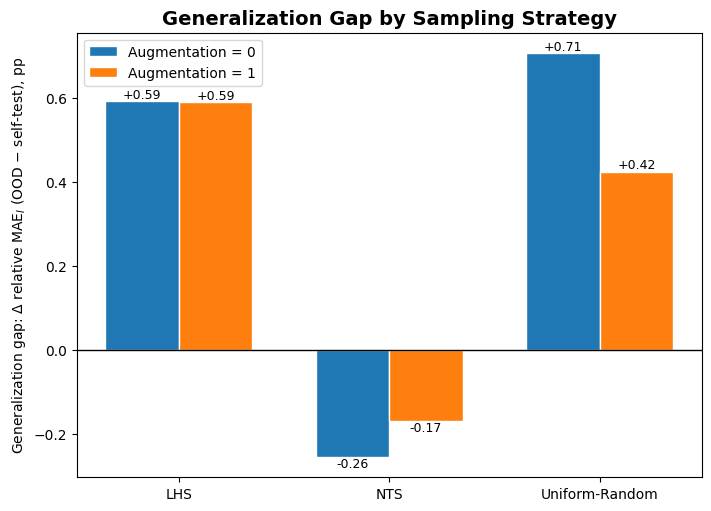

train_strategy  augmentation  relative_MAE_I_self  relative_MAE_I_ood   gap_pct
           LHS             1              4.31157            4.900760  0.589190
UNIFORM_RANDOM             1              4.42175            4.845675  0.423925
          MCMC             1              4.50650            4.337385 -0.169115
          MCMC             0              4.91067            4.655345 -0.255325
UNIFORM_RANDOM             0              6.49890            7.205650  0.706750
           LHS             0              6.53807            7.130110  0.592040


In [40]:

import matplotlib.pyplot as plt
import numpy as np

strategy_order  = ["LHS", "MCMC", "UNIFORM_RANDOM"]
strategy_labels = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform-Random"}

# Generalization gap = OOD error minus self-test error, in percentage points.
# Positive => the emulator does worse when tested on a domain it wasn't
# trained on (the usual/expected direction); negative would mean it
# generalizes *better* out-of-domain than on its own training domain.
gap = stability.copy()
gap["gap_pct"] = gap["relative_MAE_I_ood"] - gap["relative_MAE_I_self"]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

x = np.arange(len(strategy_order))
width = 0.35

for i, aug in enumerate([0, 1]):
    vals = [gap.loc[(gap["train_strategy"] == s) & (gap["augmentation"] == aug), "gap_pct"].values[0]
            for s in strategy_order]
    xpos = x + (i - 0.5) * width
    ax.bar(xpos, vals, width, label=f"Augmentation = {aug}", edgecolor="white")
    for xi, v in zip(xpos, vals):
        ax.text(xi, v, f"{v:+.2f}", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=9)

ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([strategy_labels[s] for s in strategy_order])
ax.set_ylabel(r"Generalization gap: $\Delta$ relative MAE$_I$ (OOD $-$ self-test), pp")
ax.set_title("Generalization Gap by Sampling Strategy", fontsize=14, fontweight="bold")
ax.legend()

fig.savefig("fig_generalization_delta.png", dpi=600)
plt.show()

print(gap[["train_strategy", "augmentation", "relative_MAE_I_self",
           "relative_MAE_I_ood", "gap_pct"]].to_string(index=False))

In [41]:
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)

sanity = (master_df
          .groupby(["train_strategy", "augmentation"])["relative_MAE_I"]
          .agg(mean="mean", median="median", q25=q25, q75=q75, n="count")
          .reset_index())
sanity["iqr"] = sanity["q75"] - sanity["q25"]
sanity["rank_mean"] = sanity["mean"].rank().astype(int)
sanity["rank_median"] = sanity["median"].rank().astype(int)
sanity["rank_mismatch"] = sanity["rank_mean"] != sanity["rank_median"]
sanity = sanity.sort_values("rank_mean")

print("Mean vs median/IQR sanity check per emulator (pooled across all 3 test strategies):\n")
print(sanity.to_string(index=False))
if sanity["rank_mismatch"].any():
    print("\nMean-based and median-based rankings disagree for:")
    print(sanity.loc[sanity["rank_mismatch"], ["train_strategy", "augmentation", "rank_mean", "rank_median"]].to_string(index=False))
else:
    print("\nMean-based and median-based rankings agree for every emulator -- no skew-driven distortion.")


Mean vs median/IQR sanity check per emulator (pooled across all 3 test strategies):

train_strategy  augmentation     mean  median      q25      q75  n      iqr  rank_mean  rank_median  rank_mismatch
          MCMC             1 4.393757 4.39980 4.298725 4.457400 30 0.158675          1            1          False
           LHS             1 4.704363 4.48120 4.321200 5.126175 30 0.804975          2            3           True
UNIFORM_RANDOM             1 4.704367 4.41275 4.245000 5.136650 30 0.891650          3            2           True
          MCMC             0 4.740453 4.68060 4.590625 4.838950 30 0.248325          4            4          False
           LHS             0 6.932763 6.76185 6.437475 7.395025 30 0.957550          5            6           True
UNIFORM_RANDOM             0 6.970067 6.76095 6.336850 7.357650 30 1.020800          6            5           True

Mean-based and median-based rankings disagree for:
train_strategy  augmentation  rank_mean  rank_median
     

### Simple ranking (Method 1): raw means with 95% CI

Alternative to the OLS-adjusted marginal means above: rank each emulator by its
raw (unadjusted) sample mean, pooled across the 3 test strategies, with a plain
t-based 95% CI on the mean -- no regression model, no `test_strategy` adjustment.
Both `relative_MAE_I` and `R2_I` are reported so the two metrics can be compared
directly.

In [52]:
def mean_ci(x, conf=0.95):
    x = x.dropna()
    n = len(x)
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    tcrit = scipy_stats.t.ppf(1 - (1 - conf) / 2, n - 1)
    return m, m - tcrit * se, m + tcrit * se, n

simple_rows = []
for (train, aug), g in master_df.groupby(["train_strategy", "augmentation"]):
    mae_mean, mae_lo, mae_hi, n = mean_ci(g["relative_MAE_I"])
    r2_mean, r2_lo, r2_hi, _ = mean_ci(g["R2_I"])
    simple_rows.append({
        "train_strategy": train, "augmentation": aug, "n": n,
        "mean_rel_MAE_I_%": mae_mean, "MAE_CI_lo": mae_lo, "MAE_CI_hi": mae_hi,
        "mean_R2_I": r2_mean, "R2_CI_lo": r2_lo, "R2_CI_hi": r2_hi,
    })

simple_table = pd.DataFrame(simple_rows)
simple_table["rank_MAE_I"] = simple_table["mean_rel_MAE_I_%"].rank(ascending=True).astype(int)
simple_table["rank_R2_I"] = simple_table["mean_R2_I"].rank(ascending=False).astype(int)
simple_table = simple_table.sort_values("rank_MAE_I").reset_index(drop=True)

print("Simple ranking: raw per-emulator mean\n"
      "+/- 95% CI, pooled across the 3 test strategies (no model adjustment).\n")
print(simple_table[["train_strategy", "augmentation", "n",
                     "mean_rel_MAE_I_%", "MAE_CI_lo", "MAE_CI_hi", "rank_MAE_I",
                     "mean_R2_I", "R2_CI_lo", "R2_CI_hi", "rank_R2_I"]].round(3).to_string(index=False))

n_rank_agree = (simple_table["rank_MAE_I"] == simple_table["rank_R2_I"]).sum()
print(f"\n{n_rank_agree} / {len(simple_table)} emulators get the same rank from relative_MAE_I and R2_I.")

Simple ranking: raw per-emulator mean
+/- 95% CI, pooled across the 3 test strategies (no model adjustment).

train_strategy  augmentation  n  mean_rel_MAE_I_%  MAE_CI_lo  MAE_CI_hi  rank_MAE_I  mean_R2_I  R2_CI_lo  R2_CI_hi  rank_R2_I
          MCMC             1 30             4.394      4.351      4.436           1      0.750     0.719     0.780          5
           LHS             1 30             4.704      4.521      4.888           2      0.943     0.935     0.951          1
UNIFORM_RANDOM             1 30             4.704      4.476      4.933           3      0.943     0.935     0.951          2
          MCMC             0 30             4.740      4.658      4.823           4      0.722     0.686     0.759          6
           LHS             0 30             6.933      6.680      7.185           5      0.916     0.905     0.927          4
UNIFORM_RANDOM             0 30             6.970      6.657      7.283           6      0.921     0.911     0.932          3

0 / 6 e

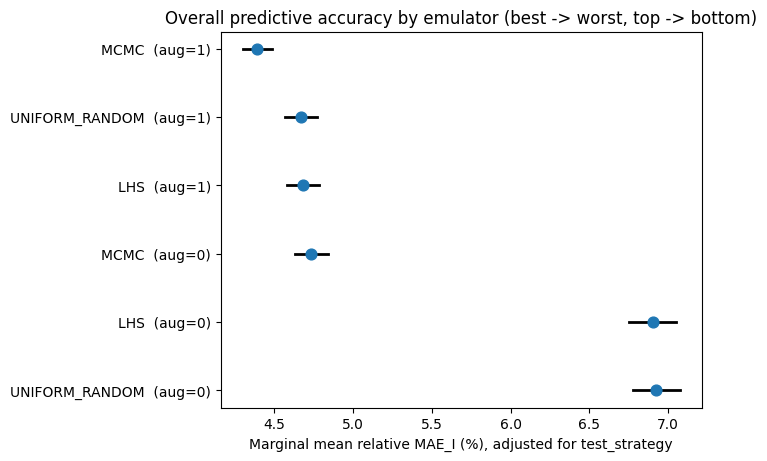

In [43]:
import matplotlib.pyplot as plt

plot_df = marginal_means.copy()
labels = [f"{t}  (aug={a})" for t, a in zip(plot_df["train_strategy"], plot_df["augmentation"])]
y = np.arange(len(plot_df))[::-1]  # best at top

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for yi, (_, row) in zip(y, plot_df.iterrows()):
    ax.plot([row["ci_lo_%"], row["ci_hi_%"]], [yi, yi], color="black", lw=2)
    ax.scatter(row["marginal_mean_%"], yi, color="tab:blue", zorder=5, s=60)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Marginal mean relative MAE_I (%), adjusted for test_strategy")
ax.set_title("Overall predictive accuracy by emulator (best -> worst, top -> bottom)")
fig.savefig("fig_forest_emulators.png", dpi=300)
plt.show()


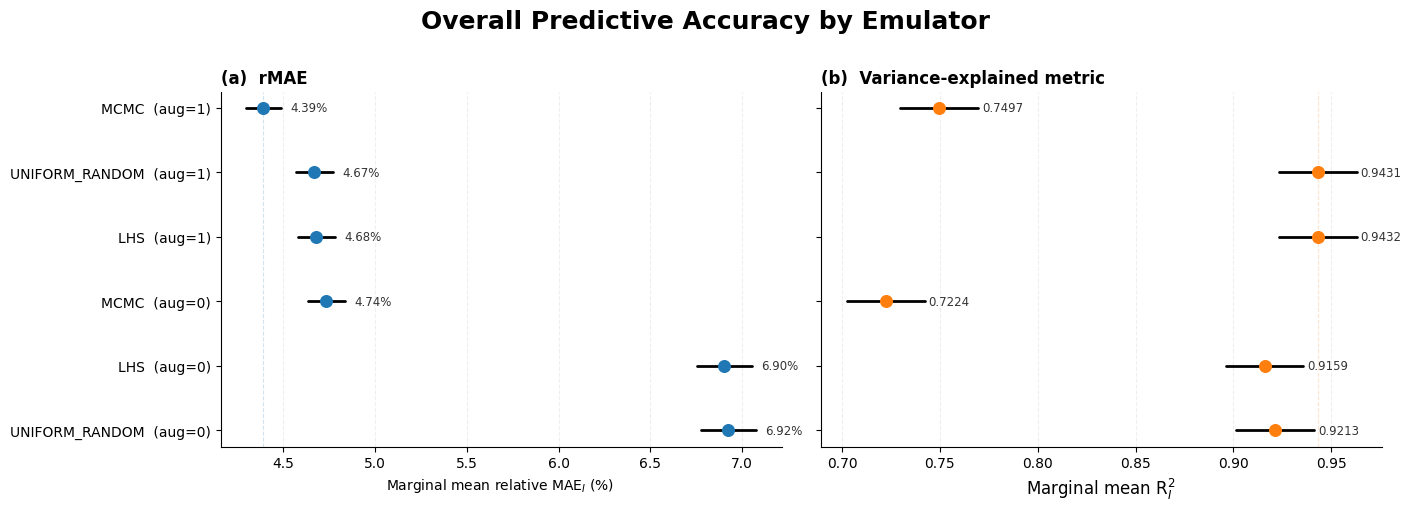

Saved.


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# ── Sort by marginal mean Rel-MAE (best emulator first = top of plot) ──
mae_sorted = results_table.sort_values(
    "Marginal mean rel. MAE_I (%)",
    ascending=True
).reset_index(drop=True)

# Y-axis labels
labels = [
    f"{t}  (aug={a})"
    for t, a in zip(mae_sorted["Train strategy"],
                    mae_sorted["Augmentation"])
]
y = np.arange(len(mae_sorted))[::-1]   # flip so best is at top

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    constrained_layout=True,
    sharey=True
)

# Panel (a): Relative MAE_I 
ax = axes[0]
for yi, (_, row) in zip(y, mae_sorted.iterrows()):
    # CI whisker
    ax.plot(
        [row["95% CI low"], row["95% CI high"]],
        [yi, yi],
        color="black", lw=2.0, solid_capstyle="round"
    )
    # Point estimate
    ax.scatter(
        row["Marginal mean rel. MAE_I (%)"], yi,
        color="tab:blue", zorder=5, s=70
    )
    # Value label
    ax.text(
        row["95% CI high"] + 0.05, yi,
        f"{row['Marginal mean rel. MAE_I (%)']:.2f}%",
        va="center", fontsize=8.5, color="#333"
    )

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Marginal mean relative MAE$_I$ (%) ",
              fontsize=10)
ax.set_title("(a)  rMAE", loc="left", fontsize=12,
             fontweight="bold")
ax.axvline(mae_sorted["Marginal mean rel. MAE_I (%)"].min(),
           color="tab:blue", lw=0.8, linestyle="--", alpha=0.2)
ax.grid(True, axis="x", alpha=0.2, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

# Panel (b): R²_I 
ax = axes[1]
for yi, (_, row) in zip(y, mae_sorted.iterrows()):
    ax.plot(
        [row["R2_I 95% CI low"], row["R2_I 95% CI high"]],
        [yi, yi],
        color="black", lw=2.0, solid_capstyle="round"
    )
    ax.scatter(
        row["Marginal mean R2_I"], yi,
        color="tab:orange", zorder=5, s=70
    )
    ax.text(
        row["R2_I 95% CI high"] + 0.002, yi,
        f"{row['Marginal mean R2_I']:.4f}",
        va="center", fontsize=8.5, color="#333"
    )

ax.set_xlabel("Marginal mean R$^2_I$ ", fontsize=12)
ax.set_title("(b)  Variance-explained metric", loc="left", fontsize=12,
             fontweight="bold")
ax.axvline(mae_sorted["Marginal mean R2_I"].max(),
           color="tab:orange", lw=0.8, linestyle="--", alpha=0.2)
ax.grid(True, axis="x", alpha=0.2, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Overall Predictive Accuracy by Emulator\n",
    fontsize=18, fontweight="bold"
)

fig.savefig("fig_forest_emulators_dual_metric.png", dpi=900,
            bbox_inches="tight")
plt.show()
print("Saved.")

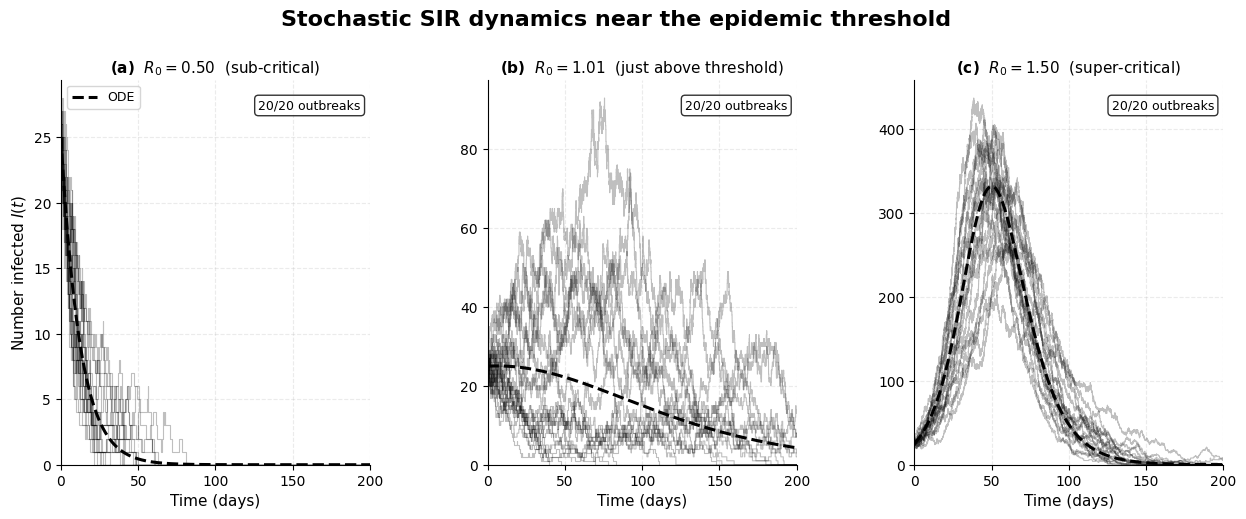

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

np.random.seed(2024)

N      = 5000
GAMMA  = 0.16
I0     = 25
S0     = N - I0
T_END  = 200
N_REAL = 20        # realisations per panel

SCENARIOS = [
    (0.50 * GAMMA, r'$R_0 = 0.50$  (sub-critical)',  'black'),
    (1.01 * GAMMA, r'$R_0 = 1.01$  (just above threshold)', 'black'),
    (1.50 * GAMMA, r'$R_0 = 1.50$  (super-critical)', 'black'),
]


# Gillespie SSA 
def gillespie_sir(beta, gamma, N, S0, I0, t_end, seed=None):
    rng = np.random.default_rng(seed)
    S, I, R = S0, I0, N - S0 - I0
    t = 0.0
    ts, Is = [t], [I]
    while t < t_end and I > 0:
        lam_inf = beta * S * I / N
        lam_rec = gamma * I
        lam_tot = lam_inf + lam_rec
        if lam_tot == 0:
            break
        t += rng.exponential(1.0 / lam_tot)
        if t > t_end:
            break
        if rng.random() < lam_inf / lam_tot:
            S -= 1; I += 1
        else:
            I -= 1; R += 1
        ts.append(t); Is.append(I)
    # pad to t_end at final value
    if ts[-1] < t_end:
        ts.append(t_end); Is.append(Is[-1])
    return np.array(ts), np.array(Is, dtype=float)


# ODE solution 
def ode_I(beta, gamma, N, S0, I0, t_end):
    def rhs(t, y):
        S, I, _ = y
        return [-beta*S*I/N, beta*S*I/N - gamma*I, gamma*I]
    t_eval = np.linspace(0, t_end, 800)
    sol = solve_ivp(rhs, [0, t_end], [S0, I0, 0],
                    t_eval=t_eval, method='RK45', rtol=1e-9)
    return sol.t, sol.y[1]


# Figure 
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

for col, (beta, title, colour) in enumerate(SCENARIOS):
    ax  = fig.add_subplot(gs[col])
    R0  = beta / GAMMA

    # Stochastic realisations
    n_extinct = 0
    for seed in range(N_REAL):
        ts, Is = gillespie_sir(beta, GAMMA, N, S0, I0, T_END, seed=seed)
        peak   = Is.max()
        extinct = peak < 5          # trivial epidemic (fewer than 5 individuals infected)
        n_extinct += int(extinct)
        ax.step(ts, Is, '-',
                color=colour, lw=0.8,
                alpha=0.25 if not extinct else 0.15,
                where='post')

    # ODE
    t_ode, I_ode = ode_I(beta, GAMMA, N, S0, I0, T_END)
    ax.plot(t_ode, I_ode, '--', color='black', lw=2.2,
            label='ODE', zorder=8)

    # Annotations
    ax.set_title(
        rf'$\mathbf{{({chr(97+col)})}}$  {title}',
        fontsize=11, pad=5
    )
    ax.text(0.97, 0.95,
            f'{N_REAL - n_extinct}/{N_REAL} outbreaks',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3',
                      fc='white', alpha=0.8, ec='black'))
    ax.set_xlabel('Time (days)', fontsize=11)
    if col == 0:
        ax.set_ylabel(r'Number infected $I(t)$', fontsize=11)
    ax.set_xlim(0, T_END)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    if col == 0:
        ax.legend(fontsize=9)

fig.suptitle(
    rf'Stochastic SIR dynamics near the epidemic threshold  ',
    fontsize=16, fontweight='bold', y=1.02)

plt.savefig("fig_stochastic_sir_threshold.png", dpi=700, bbox_inches='tight')
plt.show()
plt.close()



Discrepancy (Random): 0.0008
Discrepancy (LHS): 0.0001
Discrepancy (Sobol): 0.0000


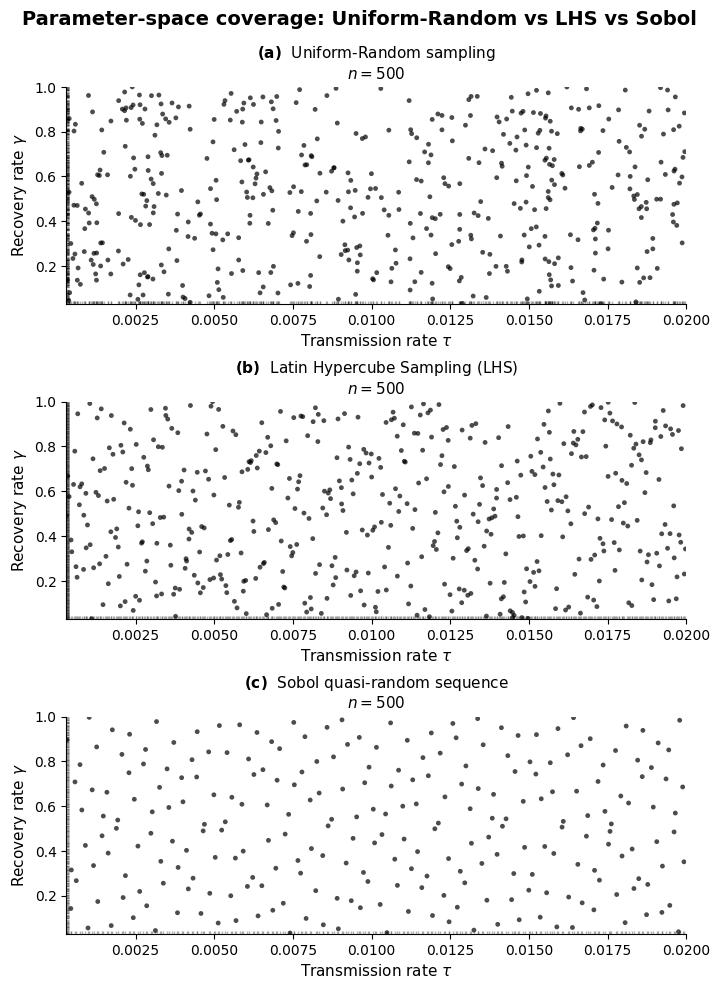

In [46]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import qmc

np.random.seed(42)

N_SAMPLES = 500

# Parameter bounds  [tau, gamma]
TAU_LO, TAU_HI   = 0.0003, 0.02
GAMMA_LO, GAMMA_HI = 0.03,   1.0

def scale(samples):
    """Scale unit-hypercube samples to [tau, gamma] bounds."""
    tau   = TAU_LO   + samples[:, 0] * (TAU_HI   - TAU_LO)
    gamma = GAMMA_LO + samples[:, 1] * (GAMMA_HI - GAMMA_LO)
    return tau, gamma


# 1. Random uniform sampling
rng = np.random.default_rng(42)
rand_raw = rng.uniform(size=(N_SAMPLES, 2))
tau_rand, gamma_rand = scale(rand_raw)

#  2. Latin Hypercube Sampling 
sampler_lhs = qmc.LatinHypercube(d=2, seed=42)
lhs_raw = sampler_lhs.random(N_SAMPLES)
tau_lhs, gamma_lhs = scale(lhs_raw)

# 3. Sobol sequence 
# n must be a power of 2 for proper Sobol; use 256 and take first 200
sampler_sobol = qmc.Sobol(d=2, scramble=True, seed=42)
sobol_raw = sampler_sobol.random(256)[:N_SAMPLES]
tau_sobol, gamma_sobol = scale(sobol_raw)


# Discrepancy (lower = more uniform coverage)
disc_rand  = qmc.discrepancy(rand_raw)
disc_lhs   = qmc.discrepancy(lhs_raw)
disc_sobol = qmc.discrepancy(sobol_raw)
for method_name, disc_value in [('Random', disc_rand), ('LHS', disc_lhs), ('Sobol', disc_sobol)]:
    print(f"Discrepancy ({method_name}): {disc_value:.4f}")


# Figure 

fig = plt.figure(figsize=(8, 11))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

configs = [
    (tau_rand,  gamma_rand,  'black', disc_rand,  'Random uniform',
     r'$\mathbf{(a)}$  Uniform-Random sampling'),
    (tau_lhs,   gamma_lhs,   'black', disc_lhs,   'LHS',
     r'$\mathbf{(b)}$  Latin Hypercube Sampling (LHS)'),
    (tau_sobol, gamma_sobol, 'black', disc_sobol, 'Sobol',
     r'$\mathbf{(c)}$  Sobol quasi-random sequence'),
]

for row, (tau, gamma, colour, disc, label, title) in enumerate(configs):
    ax = fig.add_subplot(gs[row])

    ax.scatter(tau, gamma, c=colour, s=12, alpha=0.70, edgecolors='none')

    ax.set_title(title + f'\n$n={N_SAMPLES}$', fontsize=11)
    ax.set_xlabel(r'Transmission rate $\tau$', fontsize=11)
    ax.set_ylabel(r'Recovery rate $\gamma$', fontsize=11)
    ax.set_xlim(TAU_LO, TAU_HI)
    ax.set_ylim(GAMMA_LO, GAMMA_HI)
    ax.spines[['top','right']].set_visible(False)
   

    # Marginal rug plots
    ax.plot(tau,  [GAMMA_LO]*len(tau),  '|',
            color=colour, ms=4, alpha=0.3)
    ax.plot([TAU_LO]*len(gamma), gamma, '_',
            color=colour, ms=4, alpha=0.3)

fig.suptitle(r'Parameter-space coverage: Uniform-Random vs LHS vs Sobol  ',
    fontsize=14, fontweight='bold', y=0.95)

plt.savefig("fig_sampling_coverage.png", dpi=700, bbox_inches='tight')
plt.show()
plt.close()

BA: N=5000, m=10, ratio=43.49
Homogeneous: tau=0.4000  R0=2.50
Network:     tau=0.0092   R0_net=2.50

Homogeneous (20 realisations) ...
BA network (20 realisations) ...


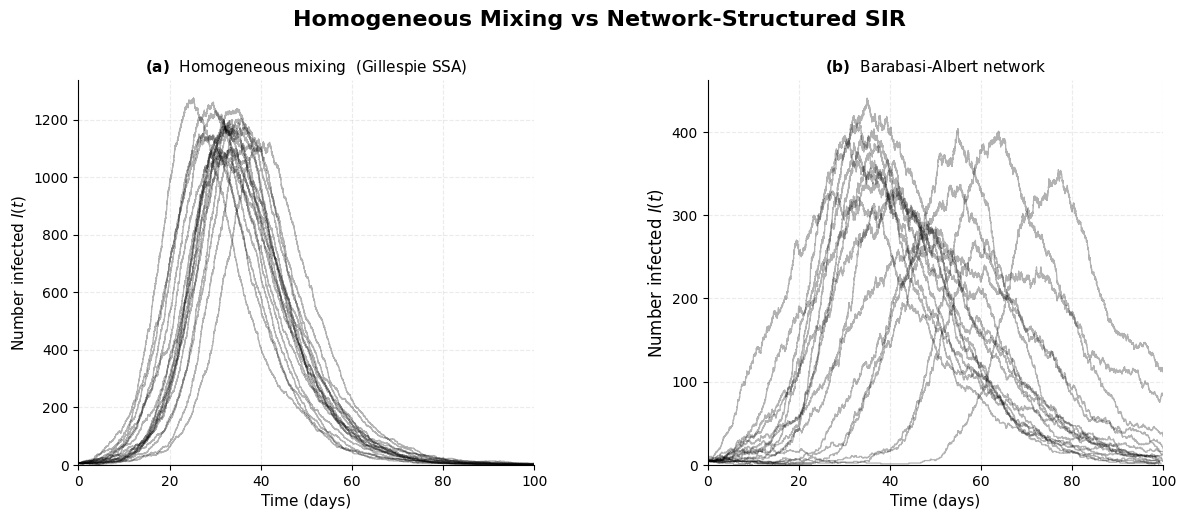

Saved fig_network_vs_homogeneous.pdf / .png


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import EoN

np.random.seed(7)

N_NET  = 5000
M_BA   = 10
GAMMA  = 0.16
N_REAL = 20
T_END  = 100
I0 = 5
R0_TARGET = 2.5

# Build fixed BA network
G  = nx.barabasi_albert_graph(N_NET, M_BA, seed=42)
degrees = np.array([d for _, d in G.degree()])
mean_k  = degrees.mean()
mean_k2 = (degrees**2).mean()
ratio   = (mean_k2-mean_k)/ mean_k

# tau for EACH model to achieve R0 = 2.5
TAU_HOMO = R0_TARGET * GAMMA               # homogeneous mixing
TAU_NET  = R0_TARGET * GAMMA / ratio       # network (smaller tau)

print(f"BA: N={N_NET}, m={M_BA}, ratio={ratio:.2f}")
print(f"Homogeneous: tau={TAU_HOMO:.4f}  R0={TAU_HOMO/GAMMA:.2f}")
print(f"Network:     tau={TAU_NET:.4f}   R0_net={TAU_NET/GAMMA*ratio:.2f}")


def gillespie_homo(N, tau, gamma, I0, t_end, seed=None):
    rng = np.random.default_rng(seed)
    S, I = N - I0, I0
    t, ts, Is = 0.0, [0.0], [I0]
    while t < t_end and I > 0:
        lam = tau * S * I / N + gamma * I
        if lam == 0: break
        t += rng.exponential(1.0 / lam)
        if t > t_end: break
        if rng.random() < (tau * S * I / N) / lam:
            S -= 1; I += 1
        else:
            I -= 1
        ts.append(t); Is.append(I)
    ts.append(t_end); Is.append(Is[-1])
    return np.array(ts), np.array(Is, dtype=float)


def network_sir_eon(G, tau, gamma, I0_count, t_end, seed=None):
    if seed is not None:
        np.random.seed(seed)
    init = np.random.choice(list(G.nodes()), I0_count, replace=False)
    t, S, I, R = EoN.fast_SIR(G, tau, gamma,
                                initial_infecteds=init,
                                tmax=t_end, return_full_data=False)
    return t, I


fig = plt.figure(figsize=(14, 5.0))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

# Panel (a) -- Homogeneous mixing
ax1 = fig.add_subplot(gs[0])
print(f"\nHomogeneous ({N_REAL} realisations) ...")
for seed in range(N_REAL):
    ts, Is = gillespie_homo(N_NET, TAU_HOMO, GAMMA, I0, T_END, seed)
    ax1.step(ts, Is, '-', color='black', lw=0.9, alpha=0.30,
             where='post')
ax1.set_title(
    r'$\mathbf{(a)}$  Homogeneous mixing  (Gillespie SSA)',
    fontsize=11)
ax1.set_xlabel('Time (days)', fontsize=11)
ax1.set_ylabel(r'Number infected $I(t)$', fontsize=11)
ax1.set_xlim(0, T_END); ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.25, linestyle='--')
ax1.spines[['top','right']].set_visible(False)

# Panel (b) -- BA network
ax2 = fig.add_subplot(gs[1])
print(f"BA network ({N_REAL} realisations) ...")
for seed in range(N_REAL):
    ts, Is = network_sir_eon(G, TAU_NET, GAMMA, I0, T_END, seed)
    ax2.step(ts, Is, '-', color='black', lw=0.9, alpha=0.30,
             where='post')
ax2.set_title(
    r'$\mathbf{(b)}$  Barabasi-Albert network',
    fontsize=11)
ax2.set_xlabel('Time (days)', fontsize=11)
ax2.set_ylabel(r'Number infected $I(t)$', fontsize=12)
ax2.set_xlim(0, T_END); ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.25, linestyle='--')
ax2.spines[['top','right']].set_visible(False)


fig.suptitle(
    r'Homogeneous Mixing vs Network-Structured SIR ',
    fontsize=16, fontweight='bold', y=1.02)

plt.savefig("fig_network_vs_homogeneous.png", dpi=700, bbox_inches='tight')
plt.savefig("fig_network_vs_homogeneous.pdf", bbox_inches='tight')
plt.show()
plt.close()
print("Saved fig_network_vs_homogeneous.pdf / .png")

In [48]:
master_df.columns.tolist()

['replicate_id',
 'train_strategy',
 'test_strategy',
 'augmentation',
 'in_domain',
 'n_train_simulations',
 'relative_MAE_I',
 'R2_I',
 'MAE_I',
 'R2_S',
 'R2_R',
 'R2_overall',
 'MAE_S',
 'MAE_R',
 'RMSE',
 'MSE',
 'mean_peak_I',
 'n_test_samples',
 'model_path',
 'training_epoch',
 'source_file',
 'peak_I',
 'condition_id',
 'log_relative_MAE_I',
 'log_R2_I',
 'resid']

Loaded 180 rows × 26 columns
Strategies: ['LHS', 'MCMC', 'UNIFORM_RANDOM']

Column summary:
  relative_MAE_I      : mean=5.4076  std=1.2285  range=[4.0850, 9.0106]
  MAE_I               : mean=142.8857  std=78.6379  range=[44.5111, 300.1722]
  R2_I                : mean=0.8659  std=0.1083  range=[0.6100, 0.9623]
  mean_peak_I         : mean=3240.6567  std=1438.0961  range=[1230.0800, 4476.4500]

SUMMARY STATISTICS FOR RESULTS SECTION

MCMC-NUTS test set (60 replicates):
  mean_peak_I :  1,230.1  ±0.0
  MAE_I       :    53.71  ±5.85
  Rel-MAE_I   :     5.97%  ±1.40%
  R²_I        :   0.8835  ±0.0242

LHS test set (60 replicates):
  mean_peak_I :  4,015.4  ±0.0
  MAE_I       :   175.58  ±52.38
  Rel-MAE_I   :     5.08%  ±1.08%
  R²_I        :   0.8540  ±0.1342

Uniform-Random test set (60 replicates):
  mean_peak_I :  4,476.5  ±0.0
  MAE_I       :   199.37  ±59.70
  Rel-MAE_I   :     5.17%  ±0.99%
  R²_I        :   0.8603  ±0.1283

Pearson correlations with mean_peak_I:
  MAE_I          

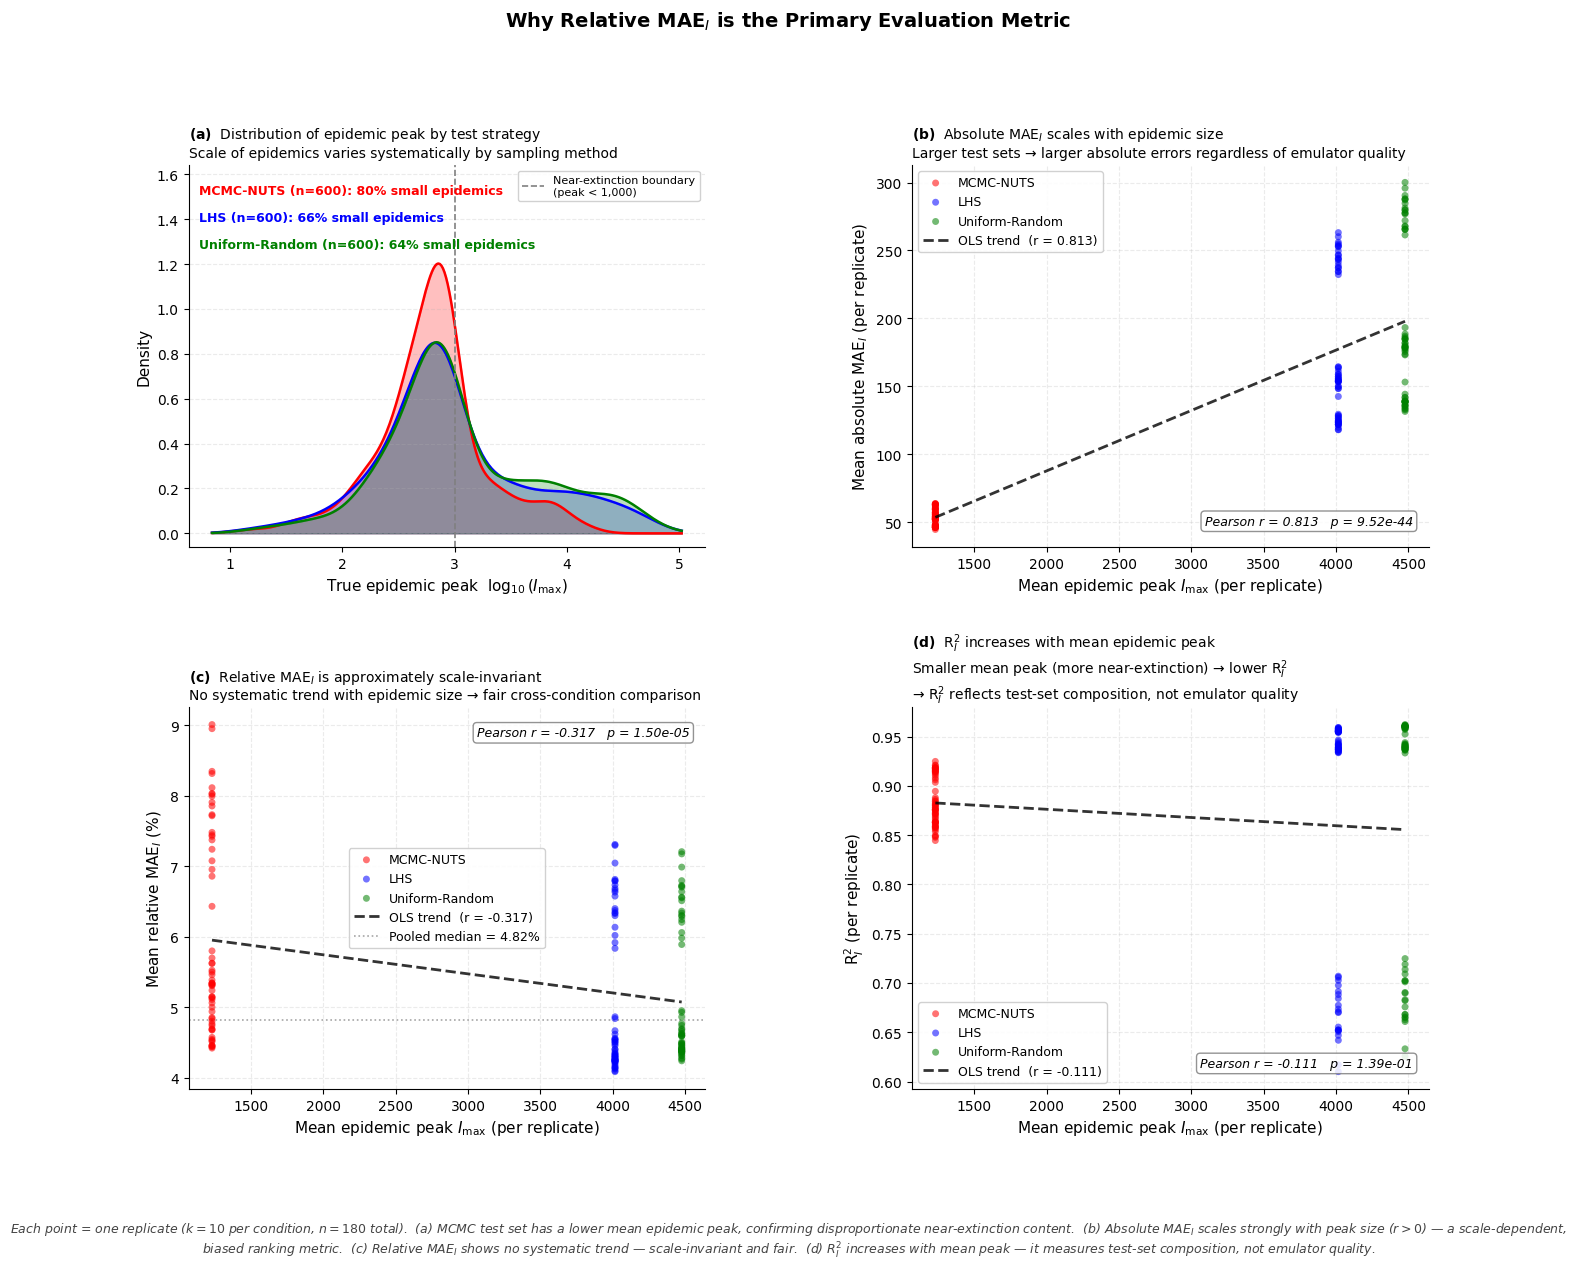

In [49]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

COLOURS = {
    'MCMC'           : 'red',
    'LHS'            : 'blue',
    'UNIFORM_RANDOM' : 'green',
}
LABELS = {
    'MCMC'           : 'MCMC-NUTS',
    'LHS'            : 'LHS',
    'UNIFORM_RANDOM' : 'Uniform-Random',
}


#  LOAD DATA


def load_master(df):
    df = df.copy()

    # Normalise strategy name spellings
    df['test_strategy']  = df['test_strategy'].str.upper().str.strip()
    df['train_strategy'] = df['train_strategy'].str.upper().str.strip()

    # Keep the three expected strategy labels
    valid = ['MCMC', 'LHS', 'UNIFORM_RANDOM']
    df = df[df['test_strategy'].isin(valid)].copy()

    print(f"Loaded {len(df)} rows × {len(df.columns)} columns")
    print(f"Strategies: {df['test_strategy'].unique().tolist()}")
    print(f"\nColumn summary:")
    for col in ['relative_MAE_I','MAE_I','R2_I','mean_peak_I']:
        if col in df.columns:
            print(f"  {col:20s}: "
                  f"mean={df[col].mean():.4f}  "
                  f"std={df[col].std():.4f}  "
                  f"range=[{df[col].min():.4f}, {df[col].max():.4f}]")
        else:
            print(f"  {col:20s}: MISSING — check column name")

    return df


def load_peak_samples():
    """Per-sample true peak_I, one row per test epidemic (n=600/strategy)."""
    files = sorted(DATA_DIR.glob("per_sample_peak_*.csv"))
    peak_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    peak_df['test_strategy']  = peak_df['test_strategy'].str.upper().str.strip()
    peak_df['train_strategy'] = peak_df['train_strategy'].str.upper().str.strip()

    # peak_I depends only on test_strategy (same test set reused across
    # train strategies) -- keep one clean copy per strategy via the self-test file
    peak_df = peak_df[peak_df['train_strategy'] == peak_df['test_strategy']]
    return peak_df[['test_strategy', 'peak_I']].reset_index(drop=True)


#  FIGURE


def make_figure(df, peak_df):

    strategies = ['MCMC', 'LHS', 'UNIFORM_RANDOM']

    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            hspace=0.42, wspace=0.40)


    #  Panel (a) — Density of epidemic peak I_max by test strategy
    # ───────────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])

    NEAR_EXTINCTION = 1000
    log_thresh = np.log10(NEAR_EXTINCTION)
    log_peak_all = np.log10(peak_df['peak_I'].clip(lower=1))
    x_grid = np.linspace(log_peak_all.min() - 0.2, log_peak_all.max() + 0.2, 300)

    for i, strat in enumerate(strategies):
        vals = np.log10(
            peak_df.loc[peak_df['test_strategy'] == strat, 'peak_I'].clip(lower=1)
        )
        density = stats.gaussian_kde(vals)(x_grid)
        ax1.plot(x_grid, density, color=COLOURS[strat], lw=1.8)
        ax1.fill_between(x_grid, density, color=COLOURS[strat], alpha=0.25)

        pct_small = (vals < log_thresh).mean() * 100
        ax1.text(0.02, 0.95 - i * 0.07,
                 f'{LABELS[strat]} (n={len(vals)}): {pct_small:.0f}% small epidemics',
                 transform=ax1.transAxes, fontsize=9, color=COLOURS[strat],
                 fontweight='bold', va='top')

    ax1.set_ylim(top=ax1.get_ylim()[1] * 1.3)
    ax1.axvline(log_thresh, color='grey', linestyle='--', lw=1.2,
                label='Near-extinction boundary\n(peak < 1,000)')

    ax1.set_xlabel(r'True epidemic peak  $\log_{10}(I_{\max})$', fontsize=11)
    ax1.set_ylabel('Density', fontsize=11)
    ax1.set_title(
        r'$\mathbf{(a)}$  Distribution of epidemic peak by test strategy'
        '\nScale of epidemics varies systematically by sampling method',
        fontsize=10, loc='left')
    ax1.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax1.grid(True, axis='y', alpha=0.25, linestyle='--')
    ax1.spines[['top','right']].set_visible(False)

    
    #  Panel (b) — Absolute MAE_I vs mean_peak_I
    
    ax2 = fig.add_subplot(gs[0, 1])

    for strat in strategies:
        sub = df[df['test_strategy'] == strat]
        ax2.scatter(sub['mean_peak_I'], sub['MAE_I'],
                    color=COLOURS[strat], s=25, alpha=0.55,
                    zorder=3, label=LABELS[strat],
                    edgecolors='none')

    # OLS trend line + Pearson r (pooled)
    x = df['mean_peak_I'].values
    y = df['MAE_I'].values
    valid = np.isfinite(x) & np.isfinite(y)
    slope, intercept, r, p_r, _ = stats.linregress(x[valid], y[valid])
    x_line = np.linspace(x[valid].min(), x[valid].max(), 200)
    ax2.plot(x_line, slope * x_line + intercept,
             'k--', lw=2.0, alpha=0.8, zorder=4,
             label=f'OLS trend  (r = {r:.3f})')

    ax2.set_xlabel(r'Mean epidemic peak $I_{\max}$ (per replicate)',
                   fontsize=11)
    ax2.set_ylabel('Mean absolute MAE$_I$ (per replicate)',  fontsize=11)
    ax2.set_title(
        r'$\mathbf{(b)}$  Absolute MAE$_I$ scales with epidemic size'
        '\nLarger test sets → larger absolute errors'
        ' regardless of emulator quality',
        fontsize=10, loc='left')
    ax2.legend(fontsize=9, framealpha=0.9)
    ax2.grid(True, alpha=0.25, linestyle='--')
    ax2.spines[['top','right']].set_visible(False)

    ax2.text(0.97, 0.05,
             f'Pearson r = {r:.3f}   p = {p_r:.2e}',
             transform=ax2.transAxes, ha='right', va='bottom',
             fontsize=9, style='italic',
             bbox=dict(boxstyle='round,pad=0.3',
                       fc='white', ec='grey', alpha=0.85))

    
    #  Panel (c) — Relative MAE_I vs mean_peak_I
    
    ax3 = fig.add_subplot(gs[1, 0])

    for strat in strategies:
        sub = df[df['test_strategy'] == strat]
        ax3.scatter(sub['mean_peak_I'], sub['relative_MAE_I'],
                    color=COLOURS[strat], s=25, alpha=0.55,
                    zorder=3, label=LABELS[strat],
                    edgecolors='none')

    # OLS trend line
    y2 = df['relative_MAE_I'].values
    valid2 = np.isfinite(x) & np.isfinite(y2)
    slope2, intercept2, r2, p_r2, _ = stats.linregress(
        x[valid2], y2[valid2]
    )
    ax3.plot(x_line, slope2 * x_line + intercept2,
             'k--', lw=2.0, alpha=0.8, zorder=4,
             label=f'OLS trend  (r = {r2:.3f})')

    # Reference: pooled median as horizontal guide
    med = df['relative_MAE_I'].median()
    ax3.axhline(med, color='grey', lw=1.2, linestyle=':',
                alpha=0.7, label=f'Pooled median = {med:.2f}%')

    ax3.set_xlabel(r'Mean epidemic peak $I_{\max}$ (per replicate)',
                   fontsize=11)
    ax3.set_ylabel('Mean relative MAE$_I$ (%)', fontsize=11)
    ax3.set_title(
        r'$\mathbf{(c)}$  Relative MAE$_I$ is approximately'
        ' scale-invariant'
        '\nNo systematic trend with epidemic size'
        r' → fair cross-condition comparison',
        fontsize=10, loc='left')
    ax3.legend(fontsize=9, framealpha=0.9)
    ax3.grid(True, alpha=0.25, linestyle='--')
    ax3.spines[['top','right']].set_visible(False)

    ax3.text(0.97, 0.95,
             f'Pearson r = {r2:.3f}   p = {p_r2:.2e}',
             transform=ax3.transAxes, ha='right', va='top',
             fontsize=9, style='italic',
             bbox=dict(boxstyle='round,pad=0.3',
                       fc='white', ec='grey', alpha=0.85))

   
    #  Panel (d) — R²_I vs mean_peak_I
   
    ax4 = fig.add_subplot(gs[1, 1])

    for strat in strategies:
        sub = df[df['test_strategy'] == strat]
        ax4.scatter(sub['mean_peak_I'], sub['R2_I'],
                    color=COLOURS[strat], s=25, alpha=0.55,
                    zorder=3, label=LABELS[strat],
                    edgecolors='none')

    # OLS trend line
    y3 = df['R2_I'].values
    valid3 = np.isfinite(x) & np.isfinite(y3)
    slope3, intercept3, r3, p_r3, _ = stats.linregress(
        x[valid3], y3[valid3]
    )
    ax4.plot(x_line, slope3 * x_line + intercept3,
             'k--', lw=2.0, alpha=0.8, zorder=4,
             label=f'OLS trend  (r = {r3:.3f})')

    ax4.set_xlabel(r'Mean epidemic peak $I_{\max}$ (per replicate)',
                   fontsize=11)
    ax4.set_ylabel('R$^2_I$ (per replicate)', fontsize=11)
    ax4.set_title(
        r'$\mathbf{(d)}$  R$^2_I$ increases with mean epidemic peak'
        '\nSmaller mean peak'
        r' (more near-extinction) → lower R$^2_I$'
        '\n→ R$^2_I$ reflects test-set composition, not emulator quality',
        fontsize=10, loc='left')
    ax4.legend(fontsize=9, framealpha=0.9)
    ax4.grid(True, alpha=0.25, linestyle='--')
    ax4.spines[['top','right']].set_visible(False)

    ax4.text(0.97, 0.05,
             f'Pearson r = {r3:.3f}   p = {p_r3:.2e}',
             transform=ax4.transAxes, ha='right', va='bottom',
             fontsize=9, style='italic',
             bbox=dict(boxstyle='round,pad=0.3',
                       fc='white', ec='grey', alpha=0.85))

    # ── Shared title and caption ───────────────────────────────────────────
    fig.suptitle(
        'Why Relative MAE$_I$ is the Primary Evaluation Metric',
        fontsize=14, fontweight='bold', y=1.01
    )
    fig.text(
        0.5, -0.025,
        r'Each point = one replicate ($k=10$ per condition, $n=180$ total).  '
        r'(a) MCMC test set has a lower mean epidemic peak, confirming'
        r' disproportionate near-extinction content.  '
        r'(b) Absolute MAE$_I$ scales strongly with peak size ($r>0$) — '
        r'a scale-dependent, biased ranking metric.  '
        r'(c) Relative MAE$_I$ shows no systematic trend — scale-invariant'
        r' and fair.  '
        r'(d) R$^2_I$ increases with mean peak — it measures test-set'
        r' composition, not emulator quality.',
        ha='center', fontsize=9, style='italic', color='#444444',
        wrap=True
    )

    plt.show()



#  PRINT SUMMARY STATISTICS FOR RESULTS SECTION

def print_summary(df):
    print("\n" + "="*65)
    print("SUMMARY STATISTICS FOR RESULTS SECTION")
    print("="*65)

    for strat in ['MCMC', 'LHS', 'UNIFORM_RANDOM']:
        sub = df[df['test_strategy'] == strat]
        print(f"\n{LABELS[strat]} test set ({len(sub)} replicates):")
        print(f"  mean_peak_I : "
              f"{sub['mean_peak_I'].mean():8,.1f}  "
              f"±{sub['mean_peak_I'].std():.1f}")
        print(f"  MAE_I       : "
              f"{sub['MAE_I'].mean():8.2f}  "
              f"±{sub['MAE_I'].std():.2f}")
        print(f"  Rel-MAE_I   : "
              f"{sub['relative_MAE_I'].mean():8.2f}%  "
              f"±{sub['relative_MAE_I'].std():.2f}%")
        print(f"  R²_I        : "
              f"{sub['R2_I'].mean():8.4f}  "
              f"±{sub['R2_I'].std():.4f}")

    # Pearson correlations with mean_peak_I
    print("\nPearson correlations with mean_peak_I:")
    x = df['mean_peak_I'].values
    for metric in ['MAE_I', 'relative_MAE_I', 'R2_I']:
        y = df[metric].values
        valid = np.isfinite(x) & np.isfinite(y)
        r, p = stats.pearsonr(x[valid], y[valid])
        sig = "***" if p < 0.001 else "**" if p < 0.01 \
              else "*" if p < 0.05 else "ns"
        print(f"  {metric:20s}:  r = {r:+.3f}   p = {p:.2e}  {sig}")



#  ENTRY POINT

peak_df = load_peak_samples()
df = load_master(master_df)
print_summary(df)
make_figure(df, peak_df)

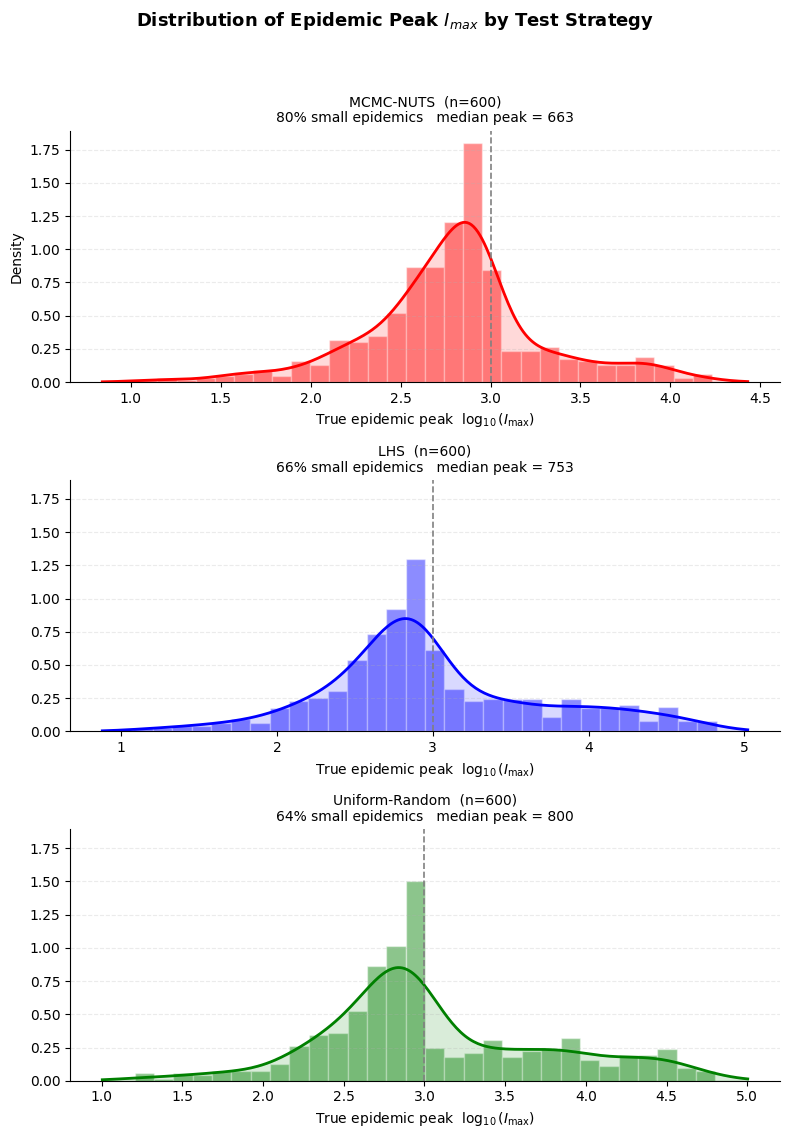

In [50]:
strategies = ['MCMC', 'LHS', 'UNIFORM_RANDOM']

NEAR_EXTINCTION = 1000
log_thresh = np.log10(NEAR_EXTINCTION)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharey=True)

for ax, strat in zip(axes, strategies):
    vals = np.log10(
        peak_df.loc[peak_df['test_strategy'] == strat, 'peak_I'].clip(lower=1)
    )

    ax.hist(vals, bins=30, density=True, color=COLOURS[strat],
            alpha=0.45, edgecolor='white')

    x_grid = np.linspace(vals.min() - 0.2, vals.max() + 0.2, 300)
    density = stats.gaussian_kde(vals)(x_grid)
    ax.plot(x_grid, density, color=COLOURS[strat], lw=2)
    ax.fill_between(x_grid, density, color=COLOURS[strat], alpha=0.15)

    ax.axvline(log_thresh, color='grey', linestyle='--', lw=1.2)

    pct_small = (vals < log_thresh).mean() * 100
    median_peak = 10 ** np.median(vals)
    ax.set_title(
        f'{LABELS[strat]}  (n={len(vals)})\n'
        f'{pct_small:.0f}% small epidemics   median peak = {median_peak:,.0f}',
        fontsize=10
    )
    ax.set_xlabel(r'True epidemic peak  $\log_{10}(I_{\max})$', fontsize=10)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Density', fontsize=10)
fig.suptitle('Distribution of Epidemic Peak $I_{max}$ by Test Strategy',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


BIC: 1-component = 3506.7   2-component = 3292.6  (2-component preferred (lower BIC))

Near-extinction component   : mean peak =      548   weight = 83.8%
Established-epidemic component: mean peak =   10,795   weight = 16.2%

Data-driven small/large threshold: peak_I = 4,191  (log10 = 3.622)

Strategy         % small epidemics
MCMC-NUTS                    93.5%
LHS                          81.8%
Uniform-Random               78.7%


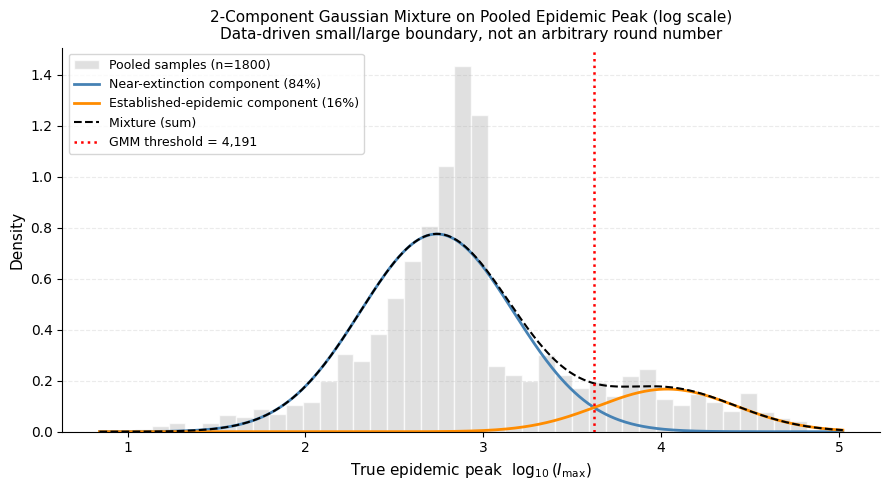

In [51]:
from sklearn.mixture import GaussianMixture

log_peak = np.log10(peak_df['peak_I'].clip(lower=1)).values.reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=0, n_init=100)
gmm.fit(log_peak)

order   = np.argsort(gmm.means_.flatten())
means   = gmm.means_.flatten()[order]
stds    = np.sqrt(gmm.covariances_.flatten())[order]
weights = gmm.weights_.flatten()[order]

# Data-driven threshold: where the two component densities cross
x_grid_fine = np.linspace(log_peak.min(), log_peak.max(), 5000)
resp_low = gmm.predict_proba(x_grid_fine.reshape(-1, 1))[:, order[0]]
gmm_thresh_log = x_grid_fine[np.where(resp_low < 0.5)[0][0]]
gmm_thresh = 10 ** gmm_thresh_log

# Is a 2-component mixture actually justified, or is 1 component enough?
bic1 = GaussianMixture(n_components=1, random_state=0).fit(log_peak).bic(log_peak)
bic2 = gmm.bic(log_peak)

print(f"BIC: 1-component = {bic1:.1f}   2-component = {bic2:.1f}  "
      f"({'2-component preferred (lower BIC)' if bic2 < bic1 else '1-component preferred'})")
print()
print(f"Near-extinction component   : mean peak = {10**means[0]:>8,.0f}   weight = {weights[0]:.1%}")
print(f"Established-epidemic component: mean peak = {10**means[1]:>8,.0f}   weight = {weights[1]:.1%}")
print()
print(f"Data-driven small/large threshold: peak_I = {gmm_thresh:,.0f}  "
      f"(log10 = {gmm_thresh_log:.3f})")
print()
print(f"{'Strategy':16s}{'% small epidemics':>18s}")
for strat in strategies:
    sub = peak_df.loc[peak_df['test_strategy'] == strat, 'peak_I']
    pct_gmm = (np.log10(sub.clip(lower=1)) < gmm_thresh_log).mean() * 100
    print(f"{LABELS[strat]:16s}{pct_gmm:17.1f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(log_peak.flatten(), bins=40, density=True, color='lightgrey',
        edgecolor='white', alpha=0.7, label='Pooled samples (n=%d)' % len(log_peak))

x_grid_plot = np.linspace(log_peak.min() - 0.2, log_peak.max() + 0.2, 500)
comp0 = weights[0] * stats.norm.pdf(x_grid_plot, means[0], stds[0])
comp1 = weights[1] * stats.norm.pdf(x_grid_plot, means[1], stds[1])
ax.plot(x_grid_plot, comp0, color='steelblue', lw=2,
        label=f'Near-extinction component ({weights[0]:.0%})')
ax.plot(x_grid_plot, comp1, color='darkorange', lw=2,
        label=f'Established-epidemic component ({weights[1]:.0%})')
ax.plot(x_grid_plot, comp0 + comp1, color='black', lw=1.5, linestyle='--',
        label='Mixture (sum)')

ax.axvline(gmm_thresh_log, color='red', linestyle=':', lw=1.8,
           label=f'GMM threshold = {gmm_thresh:,.0f}')

ax.set_xlabel(r'True epidemic peak  $\log_{10}(I_{\max})$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    '2-Component Gaussian Mixture on Pooled Epidemic Peak (log scale)\n'
    'Data-driven small/large boundary, not an arbitrary round number',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.25, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


test_strategy    train_strategy    mean R2_I
LHS              LHS               0.946
                 MCMC              0.667   ← collapse
                 UNIFORM_RANDOM    0.949
UNIFORM_RANDOM   LHS               0.949
                 MCMC              0.682   ← collapse
                 UNIFORM_RANDOM    0.950
MCMC             LHS               0.894
                 MCMC               0.859
                 UNIFORM_RANDOM    0.898
